In [1]:
import pandas as pd
from pathlib import Path
import pyarrow.parquet as pq
from dataclasses import dataclass
import hvplot.pandas 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import re
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
import numpy as np
import random
import time
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Extracting and Preparing Data

In [11]:
dataset_root = Path(r"./dataset") # Raw string works without escaping \


@dataclass
class Case():
    info: pd.DataFrame
    measurements: pd.DataFrame


class RawDataset():

    def __init__(self, root, unit = "VG4", load_training=False, load_synthetic=False) -> None:
        
        
        read_pq_file = lambda f: pq.read_table(root / f).to_pandas()
        
        
        cases = {
            "test": [f"{unit}_generator_data_testing_real_measurements.parquet", root / f"{unit}_generator_data_testing_real_info.csv" ], 
        }
        
        if load_training:
            cases = {
                **cases,
                "train": [f"{unit}_generator_data_training_measurements.parquet", root / f"{unit}_generator_data_training_info.csv" ], 
            }
        
        if load_synthetic:
            cases = {
                **cases,
                "test_s01": [f"{unit}_generator_data_testing_synthetic_01_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_01_info.csv"], 
                "test_s02": [f"{unit}_generator_data_testing_synthetic_02_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_02_info.csv"]
            }
        
        
        self.data_dict = dict()
        
        for id_c, c in cases.items():
            # if you need to verify the parquet header:
            # pq_rows = RawDataset.read_parquet_schema_df(root / c[0])
            info = pd.read_csv(c[1])
            measurements = read_pq_file(c[0])
            self.data_dict[id_c] = Case(info, measurements)
            
        
        
    @staticmethod
    def read_parquet_schema_df(uri: str) -> pd.DataFrame:
        """Return a Pandas dataframe corresponding to the schema of a local URI of a parquet file.

        The returned dataframe has the columns: column, pa_dtype
        """
        # Ref: https://stackoverflow.com/a/64288036/
        schema = pq.read_schema(uri, memory_map=True)
        schema = pd.DataFrame(({"column": name, "pa_dtype": str(pa_dtype)} for name, pa_dtype in zip(schema.names, schema.types)))
        schema = schema.reindex(columns=["column", "pa_dtype"], fill_value=pd.NA)  # Ensures columns in case the parquet file has an empty dataframe.
        return schema

## Splitting the dataset

In [12]:
# Define Operating Modes
Operating_modes_name = [
    "turbine_mode", "equilibrium_turbine_mode", "pump_mode", "equilibrium_pump_mode",
    "short_circuit_mode", "equilibrium_short_circuit_mode", "machine_on", "machine_off", 
    "dyn_only_on", "all"
]

# Time Series Extraction Functions
def extracting_name_groups_time_series(rds, set_type):
    df_name_control_sensors = rds.data_dict[set_type].info
    control_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == True) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    sensors_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == False) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    return control_time_series_name["attribute_name"], sensors_time_series_name["attribute_name"]

def extracting_groups_time_series(rds, set_type):
    control_time_series_name, sensors_time_series_name = extracting_name_groups_time_series(rds, set_type=set_type)
    control_df = rds.data_dict[set_type].measurements[control_time_series_name]
    sensors_df = rds.data_dict[set_type].measurements[sensors_time_series_name]
    operating_modes_df = rds.data_dict[set_type].measurements[Operating_modes_name]
    return control_df, sensors_df, operating_modes_df

def get_indexes_operating_mode(operating_modes_df, operating_conditions):
    mask = pd.Series([True] * len(operating_modes_df), index=operating_modes_df.index)
    for column, value in operating_conditions.items():
        mask &= (operating_modes_df[column] == value)
    return operating_modes_df[mask].index

# Helper functions for feature extraction and normalization
def create_scaled_sum_feature(df, feature_prefixes, new_feature_name):
    feature_columns = df.columns[df.columns.str.startswith(tuple(feature_prefixes))]
    df[new_feature_name] = df[feature_columns].sum(axis=1)
    scaler = MinMaxScaler()
    df[new_feature_name] = scaler.fit_transform(df[[new_feature_name]])
    df.drop(columns=feature_columns, inplace=True)
    return df

def normalize_features(df):
    scaler = MinMaxScaler()
    numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
    df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
    return df

def dynamic_group_features(df):
    feature_groups = {
        'voltage_current': df.columns[df.columns.str.startswith(("exc", "ph", "elec", "mid", "neutral"))].tolist(),
        'stator_temperature': df.columns[df.columns.str.startswith("stat_") & 
                                         df.columns.str.contains("coil|magn")].tolist(),
        'cooling_system': df.columns[df.columns.str.startswith("air_circ_")].tolist(),
        'heat_exchanger': df.columns[df.columns.str.startswith("water_circ_")].tolist()
    }

    # Flatten the list of all grouped features
    grouped_features = [feature for group in feature_groups.values() for feature in group]
    # Find complementary features
    complementary_features = [col for col in df.columns if col not in grouped_features]
    
    feature_groups['complementary'] = complementary_features

    return feature_groups

def preprocess_hydraulic_data(rds, set_type, operating_conditions):
    """
    Preprocess the hydraulic site data to return normalized control and sensor signals filtered by operating conditions.

    Parameters:
    - rds: RawDataset object containing the data dictionary
    - set_type: Type of dataset to use ('train', 'test', etc.)
    - feature_group: The group of sensor features to select for preprocessing
    - operating_conditions: A dictionary specifying operating conditions to filter the data
    
    Returns:
    - Dictionary with two normalized and filtered DataFrames: control signals and sensor signals
    """
    # Step 1: Extract control, sensor, and operating mode time series
    control_df, sensors_df, operating_modes_df = extracting_groups_time_series(rds, set_type=set_type)

    # Step 2: Filter based on operating conditions if specified
    if operating_conditions:
        indexes = get_indexes_operating_mode(operating_modes_df, operating_conditions)
        control_df = control_df.loc[indexes]
        sensors_df = sensors_df.loc[indexes]
        
    # Select features containing both 'water' and 'opening' in their name
    water_opening_features = [col for col in control_df.columns if "water" in col and "opening" in col]
    control_df = create_scaled_sum_feature(control_df, water_opening_features, "water_opening_sum")

    # Select features containing both 'injector' and 'opening' in their name
    injector_opening_features = [col for col in control_df.columns if "injector" in col and "opening" in col]
    control_df = create_scaled_sum_feature(control_df, injector_opening_features, "injector_opening_sum")

    # Step 4: Normalize the control and sensor DataFrames
    control_df = normalize_features(control_df)
    sensors_df = normalize_features(sensors_df)

    # Step 5: Select only the sensor features corresponding to the specified feature group
    grouped_data = dynamic_group_features(sensors_df)
    selected_sensor_data = []
    for key in grouped_data.keys():
        selected_sensor_data.append(sensors_df[grouped_data[key]])

    return {
        'control_signals': control_df,
        'sensor_signals': selected_sensor_data
    }

# Loading Train Dataset

In [62]:
rds_u5_train = RawDataset(dataset_root, "VG5", load_synthetic=False, load_training=True)

# Turbine Steady State Operation
operating_conditions_set = {
    "dyn_only_on": False, "turbine_mode": True, "equilibrium_turbine_mode": True, "short_circuit_mode": False
}

# Preprocess data to get normalized control and sensor signals based on conditions
rds_u5_turb_ss_volt = preprocess_hydraulic_data(
    rds_u5_train, set_type="train", operating_conditions=operating_conditions_set
)

del rds_u5_train # To free memory
control_df_train = rds_u5_turb_ss_volt['control_signals']
sensors_df_train = rds_u5_turb_ss_volt['sensor_signals']

# Split sensor into 5 different subgroups
sensors_voltage_current = sensors_df_train[0]
sensors_stator_temperature = sensors_df_train[1]
sensors_cooling_system = sensors_df_train[2]
sensors_heat_exchanger = sensors_df_train[3]
sensors_other = sensors_df_train[4]

C:\Users\Jiasheng\AppData\Local\Temp\ipykernel_20272\4265801486.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


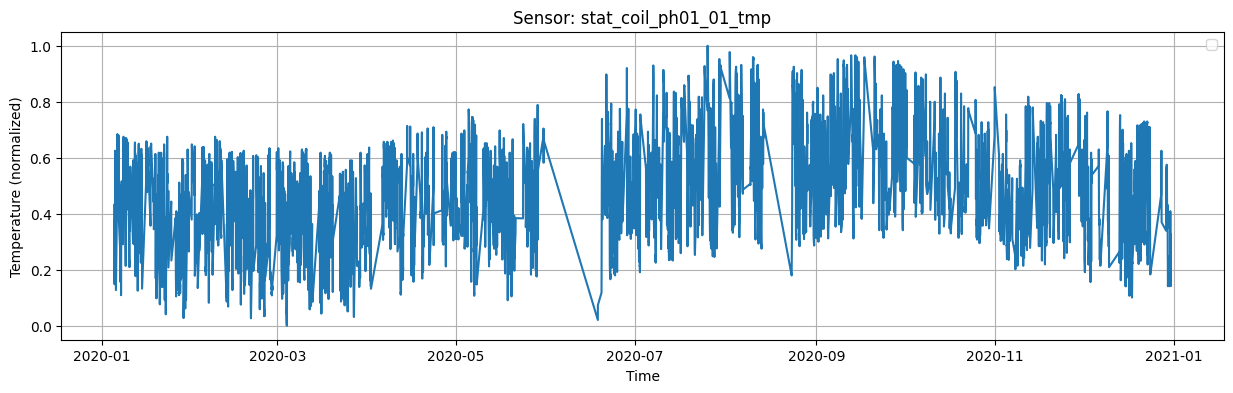

In [63]:
first_sensor_name = sensors_stator_temperature.columns[0]

plt.figure(figsize=(15, 4))
plt.plot(sensors_stator_temperature.iloc[:, 2])
plt.title(f'Sensor: {first_sensor_name}')
plt.xlabel('Time')
plt.ylabel('Temperature (normalized)')
plt.grid(True)
plt.legend()
plt.show()

# Start of 1D CNN

In [64]:
class SlidingWindowDataset(Dataset):
    def __init__(self, control_df, sensor_df, window=50, stride=1, horizon=1, device='cpu'):
        """Sliding window dataset for temperature prediction

        Args:
            control_df (pd.DataFrame): DataFrame containing control signals
            sensor_df (pd.DataFrame): DataFrame containing stator temperature readings
            window (int, optional): sequence window length. Defaults to 50.
            stride (int, optional): data stride length. Defaults to 1.
            horizon (int, optional): prediction forecasting length. Defaults to 1.
        """
        self.window = window
        self.stride = stride
        self.horizon = horizon
        
        # Point mapping
        self.X = control_df.values.astype(np.float32)         # Only control signals (X_t)
        self.y = sensor_df.values.astype(np.float32)          # Sensor measurements (Y_t)
        
        # Calculate valid indices for sliding windows
        self.indices = self._get_indices()
        self.indices = torch.from_numpy(self.indices).to(device)

    def _get_indices(self):
        """Calculate valid indices for sliding windows"""
        valid_length = len(self.X) - self.window - self.horizon + 1
        idx_list = [i for i in range(0, valid_length, self.stride)]
        return np.asarray([(idx, idx+self.window) for idx in idx_list])

    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, i):
        i_start, i_stop = self.indices[i]
        x = self.X[i_start:i_stop, :]
        y = self.y[i_stop + self.horizon - 1]  # Target is horizon steps ahead
        x = torch.from_numpy(x).transpose(0, 1)  # Shape: (features, sequence_length)
        y = torch.from_numpy(y)
        return x, y

# def create_datasets(control_df, sensor_df, window_size, train_indices, test_indices, device='cpu'):
#     """Create train and test datasets"""
#     # Split data according to indices
#     control_train = control_df.iloc[train_indices]
#     sensor_train = sensor_df.iloc[train_indices]
    
#     control_test = control_df.iloc[test_indices]
#     sensor_test = sensor_df.iloc[test_indices]
    
#     # Create datasets
#     train_dataset = SlidingWindowDataset(control_train, sensor_train, window=window_size, device=device)
#     test_dataset = SlidingWindowDataset(control_test, sensor_test, window=window_size, device=device)
    
#     # Normalize features using training data
#     scaler = MinMaxScaler()
#     train_dataset.X = scaler.fit_transform(train_dataset.X)
#     test_dataset.X = scaler.transform(test_dataset.X)
    
#     return train_dataset, test_dataset

def create_data_loaders(dataset, batch_size=256, val_split=0.2):
    """Create train and validation data loaders from a single dataset"""
    # Set random seed for reproducibility
    random.seed(0)
    np.random.seed(0)
    
    # Calculate split
    dataset_size = len(dataset)
    indices = list(range(dataset_size))
    split = int(np.floor(val_split * dataset_size))
    
    # Shuffle indices
    np.random.shuffle(indices)
    train_indices, val_indices = indices[split:], indices[:split]
    
    # Create samplers
    train_sampler = SubsetRandomSampler(train_indices)
    valid_sampler = SubsetRandomSampler(val_indices)
    
    # Create data loaders
    train_loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        sampler=train_sampler
    )
    val_loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        sampler=valid_sampler
    )
    
    print(f"\nDataset sizes:")
    print(f"Train: {len(train_indices)}")
    print(f"Validation: {len(val_indices)}")
    
    return train_loader, val_loader

def seed_everything(seed: int):
    r"""Sets the seed for generating random numbers in PyTorch, numpy and
    Python.

    Args:
        seed (int): The desired seed.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def init_weights(m):
    """Initialize neural network weights"""
    if isinstance(m, nn.BatchNorm1d):
        m.weight.data.fill_(1.0)
        m.bias.data.zero_()
    elif isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
        m.weight.data = nn.init.xavier_uniform_(
            m.weight.data, gain=nn.init.calculate_gain('relu'))
        if m.bias is not None:
            m.bias.data.zero_()

class Trainer:
    def __init__(
        self,
        model,
        optimizer,
        n_epochs=20,
        criterion=nn.MSELoss(),
        model_name='best_model',
        seed=42,
        device='cpu'
    ):
        self.seed = seed
        self.model = model
        self.optimizer = optimizer
        self.device = device
        self.n_epochs = n_epochs
        self.criterion = criterion
        
        # Create models directory if it doesn't exist
        os.makedirs('models', exist_ok=True)
        
        # Model saving
        time_stamp = time.strftime("%m%d%H%M%S")
        self.model_path = f'models/{model_name}_{time_stamp}.pt'
        
        self.losses = {split: [] for split in ['train', 'eval', 'test']}

    # Add these methods
    def save(self, model, model_path=None):
        """Save model state dict"""
        if model_path is None:
            model_path = self.model_path
        torch.save(model.state_dict(), model_path)
        
    def load(self, model, model_path=None):
        """Load model state dict"""
        if model_path is None:
            model_path = self.model_path
        model.load_state_dict(torch.load(model_path, map_location=self.device))
        print(f"Model loaded from {model_path}")
        return model

    def compute_loss(self, x, y, model=None):
        y = y.view(-1)
        y_pred = self.model(x)
        y_pred = y_pred.view(-1)
        loss = self.criterion(y, y_pred)
        return loss, y_pred, y
    
    def train_epoch(self, loader):
        self.model.train()
        b_losses = []
        with tqdm(loader, desc="Training", unit="batch") as t_loader:
            for x, y in t_loader:
                self.optimizer.zero_grad()
                x.to(torch.device(self.device))
                y.to(torch.device(self.device))
                
                loss, pred, target = self.compute_loss(x, y)
                
                loss.backward()
                self.optimizer.step()
                b_losses.append(loss.detach().numpy())
                
                t_loader.set_postfix(loss=loss.item())
        
        agg_loss = np.sqrt((np.asarray(b_losses) ** 2).mean())
        self.losses['train'].append(agg_loss)
        return agg_loss
    
    @torch.no_grad()
    def eval_epoch(self, loader, split='eval'):
        self.model.eval()
        b_losses = []
        with tqdm(loader, desc=f"Evaluating ({split})", unit="batch") as t_loader:
            for x, y in t_loader:
                x.to(torch.device(self.device))
                y.to(torch.device(self.device))
                
                loss, pred, target = self.compute_loss(x, y)
                
                b_losses.append(loss.detach().numpy())
                t_loader.set_postfix(loss=loss.detach().numpy())
        
        agg_loss = np.sqrt((np.asarray(b_losses) ** 2).mean())
        self.losses[split].append(agg_loss)
        return agg_loss
    
    def fit(self, train_loader, val_loader):
        """Train the model"""
        print(f"Training model for {self.n_epochs} epochs...")
        train_start = time.time()  # Added total time tracking from first version
        best_val_loss = float('inf')
        
        for epoch in range(self.n_epochs):
            epoch_start = time.time()
            
            print(f"\nEpoch {epoch + 1}/{self.n_epochs}")
            
            # Training phase
            train_loss = self.train_epoch(train_loader)
            
            # Validation phase
            val_loss = self.eval_epoch(val_loader, split='eval')
            
            # Save best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                self.save(self.model, self.model_path)  # Added model_path from first version
                print(f"Epoch {epoch + 1}: New best model saved!")
            
            # More structured logging from first version
            s = (
                f"[Epoch {epoch + 1}] "
                f"train_loss = {train_loss:.5f}, "
                f"val_loss = {val_loss:.5f}"
            )
            epoch_time = time.time() - epoch_start
            s += f" [{epoch_time:.1f}s]"
            print(s)
        
        # Added total time reporting from first version
        train_time = int(time.time() - train_start)
        print(f'Training completed in {train_time}s!')


    @torch.no_grad()
    def eval_prediction(self, test_loader):
        """Evaluate predictions for anomaly detection"""
        print("Evaluating predictions...")
        
        best_model = self.load(self.model)  # Load best model
        best_model.eval()
        
        preds = []
        trues = []
        
        for x, y in tqdm(test_loader):
            x = x.to(self.device)
            y = y.to(self.device)
            
            _, y_pred, y_target = self.compute_loss(x, y)  # Use compute_loss for consistency
            preds.append(y_pred.cpu().numpy())
            trues.append(y_target.cpu().numpy())
        
        preds = np.concatenate(preds, axis=0)
        trues = np.concatenate(trues, axis=0)
        
        print(f"Predictions shape: {preds.shape}")
        print(f"True values shape: {trues.shape}")
        
        # Create sensor-wise DataFrames
        dfs = []
        for sensor_idx in range(preds.shape[1]):
            df = pd.DataFrame({
                'pred': preds[:, sensor_idx],
                'true': trues[:, sensor_idx],
                'error': preds[:, sensor_idx] - trues[:, sensor_idx],
                'abs_error': np.abs(preds[:, sensor_idx] - trues[:, sensor_idx]),
                'sensor': sensor_idx
            })
            dfs.append(df)
        
        # Combine all sensor DataFrames
        df_all = pd.concat(dfs, axis=0, ignore_index=True)
        
        # Calculate metrics
        overall_rmse = np.sqrt(np.mean((preds - trues) ** 2))
        sensor_rmse = np.sqrt(np.mean((preds - trues) ** 2, axis=0))
        
        # Create metrics DataFrame including both RMSE and seed
        df_metrics = pd.DataFrame({
            'sensor': list(range(len(sensor_rmse))) + ['overall'],
            'rmse': np.append(sensor_rmse, overall_rmse),
            'seed': self.seed
        })
        
        print("\nMetrics Summary:")
        print(f"Overall RMSE: {overall_rmse:.4f}")
        print("Sensor-wise RMSE:", sensor_rmse)
        
        return df_all, df_metrics

def plot_training_losses(trainer):
    plt.figure(figsize=(10, 6))
    
    linestyles = {
        'train': 'solid', 
        'eval': 'dashed'
    }
    
    colors = {
        'train': 'blue',
        'eval': 'red'
    }
    
    # Only iterate over train and eval losses
    for split in ['train', 'eval']:
        if split in trainer.losses:  # Ensure the split exists in the losses dictionary
            plt.plot(
                range(1, 1 + len(trainer.losses[split])), 
                trainer.losses[split], 
                label=f'{split} loss', 
                linestyle=linestyles[split],
                color=colors[split],
                marker='o',
                markersize=4
            )
    
    plt.title("Training/Validation Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.yscale('log')
    
    # Add minor gridlines
    plt.grid(True, which='minor', linestyle=':', alpha=0.4)
    
    # Tight layout to prevent label cutoff
    plt.tight_layout()
    plt.show()

### CNN Architecture

In [ ]:
class CNN(nn.Module):
    def __init__(self, 
                 in_channels, 
                 out_channels,
                 window=50, 
                 n_ch=10, 
                 n_k=10, 
                 n_hidden=50, 
                 n_layers=3,
                 dropout=0.1,
                 padding='same',
                 use_batchnorm=False):
    
        super().__init__()
        
        # Create conv layers
        self.conv_layers = nn.ModuleList()
        
        # First layer
        self.conv_layers.append(nn.Sequential(
            nn.Conv1d(in_channels, n_ch, kernel_size=n_k, padding=padding),
            nn.BatchNorm1d(n_ch) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout)
        ))
        
        # Middle layers
        for _ in range(n_layers - 2):
            self.conv_layers.append(nn.Sequential(
                nn.Conv1d(n_ch, n_ch, kernel_size=n_k, padding=padding),
                nn.BatchNorm1d(n_ch) if use_batchnorm else nn.Identity(),
                nn.LeakyReLU(0.1),
                nn.Dropout(dropout)
            ))
        
        # Final conv layer
        self.conv_layers.append(nn.Sequential(
            nn.Conv1d(n_ch, n_ch, kernel_size=n_k, padding=padding),
            nn.BatchNorm1d(n_ch) if use_batchnorm else nn.Identity(),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout)
        ))
        
        # Fully connected layers
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_ch * window, n_hidden),
            nn.BatchNorm1d(n_hidden) if use_batchnorm else nn.Identity(),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout),
            nn.Linear(n_hidden, n_hidden // 2),
            nn.LeakyReLU(0.1),
            nn.Linear(n_hidden // 2, out_channels)
        )
        
        # Initialize weights
        self.apply(init_weights)
        
    def forward(self, x):
        # Pass through all conv layers sequentially
        for layer in self.conv_layers:
            x = layer(x)
        x = self.regressor(x)
        return x
    
# Input:          [256, 18, 50]  # (batch, features, window)
# After layer1:   [256, 10, 50]  # (batch, channels, window)
# After layer2:   [256, 10, 50]  # (batch, channels, window)
# After layer3:   [256, 1, 50]   # (batch, channels, window)
# After flatten:  [256, 50]      # (batch, flattened)
# Final output:   [256, 1]       # (batch, prediction)

## Initialize 1D CNN Model

In [69]:
SENSOR_GROUPS = {
    'stator_temperature': sensors_stator_temperature,
    'voltage_current': sensors_voltage_current,
    'cooling_system': sensors_cooling_system,
    'heat_exchanger': sensors_heat_exchanger,
    'other': sensors_other
}

SELECTED_SENSOR_GROUP_KEY = 'stator_temperature'  # Use the key to select the sensor group

# Dynamically generate DEFAULT_PARAMS
DEFAULT_PARAMS = {
    # CNN model parameters
    'in_channels': len(control_df_train.columns),  # Control features
    'out_channels': len(SENSOR_GROUPS[SELECTED_SENSOR_GROUP_KEY].columns),  # Sensor group features
    'window': 75,
    'n_ch': 32,
    'n_k': 5,  # Kernel size
    'n_hidden': 50,
    'n_layers': 3,
    'dropout': 0.1,
    'padding': 'same',
    'use_batchnorm': True,

    # Training parameters
    'batch_size': 256,
    'base_lr': 1e-3,
    'weight_decay': 1e-5,
    'max_epochs': 40
}


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def init_model(params):
    """Initialize CNN model with given parameters."""
    model = CNN(
        in_channels=params['in_channels'],
        out_channels=params['out_channels'],
        window=params['window'],
        n_ch=params['n_ch'],
        n_k=params['n_k'],
        n_hidden=params['n_hidden'],
        n_layers=params['n_layers'],
        dropout=params['dropout'],
        padding=params['padding'],
        use_batchnorm=params['use_batchnorm']
    ).to(device)

    print(model)
    return model

def setup_training(selected_sensor_group_key, params=DEFAULT_PARAMS):
    """Setup training with the selected sensor group."""
    print(f"\nSetting up training for {selected_sensor_group_key}")
    print(f"Input channels: {params['in_channels']}")
    print(f"Output channels: {params['out_channels']}")

    # Skip normalization since data is already normalized
    control_norm = control_df_train
    sensor_norm = SENSOR_GROUPS[selected_sensor_group_key]  # Retrieve the DataFrame dynamically

    # Create dataset
    dataset = SlidingWindowDataset(
        control_norm,
        sensor_norm,
        window=params['window']
    )
    
    # Create loaders
    train_loader, val_loader = create_data_loaders(
        dataset,
        batch_size=params['batch_size'],
        val_split=0.2
    )
    
    return train_loader, val_loader

In [70]:
SEED = 42
seed_everything(SEED)

# Set up training
train_loader, val_loader = setup_training(SELECTED_SENSOR_GROUP_KEY, DEFAULT_PARAMS)

# Initialize model
model = init_model(DEFAULT_PARAMS)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=DEFAULT_PARAMS['base_lr'],
    weight_decay=DEFAULT_PARAMS['weight_decay']
)

# Create and run trainer
criterion = nn.MSELoss()
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    n_epochs=DEFAULT_PARAMS['max_epochs'],
    device=device,
    seed = SEED,
)

trainer.fit(train_loader, val_loader)


Setting up training for stator_temperature
Input channels: 9
Output channels: 30

Dataset sizes:
Train: 265728
Validation: 66432
CNN(
  (conv_layers): ModuleList(
    (0): Sequential(
      (0): Conv1d(9, 32, kernel_size=(5,), stride=(1,), padding=same)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
    )
    (1-2): 2 x Sequential(
      (0): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=same)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
    )
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2400, out_features=50, bias=True)
    (2): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.1, inplace=False)
    (5): Linear(in_features=50, out_features=30, bias=Tr

Evaluating (eval): 100%|██████████| 260/260 [00:03<00:00, 73.48batch/s, loss=0.011295189] 


Epoch 1: New best model saved!
[Epoch 1] train_loss = 0.12794, val_loss = 0.01084 [35.8s]

Epoch 2/40


Evaluating (eval): 100%|██████████| 260/260 [00:03<00:00, 71.49batch/s, loss=0.012143589] 


[Epoch 2] train_loss = 0.01367, val_loss = 0.01184 [35.7s]

Epoch 3/40


...

Epoch 38: New best model saved!
[Epoch 38] train_loss = 0.00433, val_loss = 0.00473 [80.1s]

Epoch 39/40


Evaluating (eval): 100%|██████████| 260/260 [00:06<00:00, 37.41batch/s, loss=0.0041459478]


Epoch 39: New best model saved!
[Epoch 39] train_loss = 0.00433, val_loss = 0.00460 [61.5s]

Epoch 40/40


Evaluating (eval): 100%|██████████| 260/260 [00:10<00:00, 25.40batch/s, loss=0.003823976] 


Epoch 40: New best model saved!
[Epoch 40] train_loss = 0.00433, val_loss = 0.00453 [107.1s]
Training completed in 3547s!


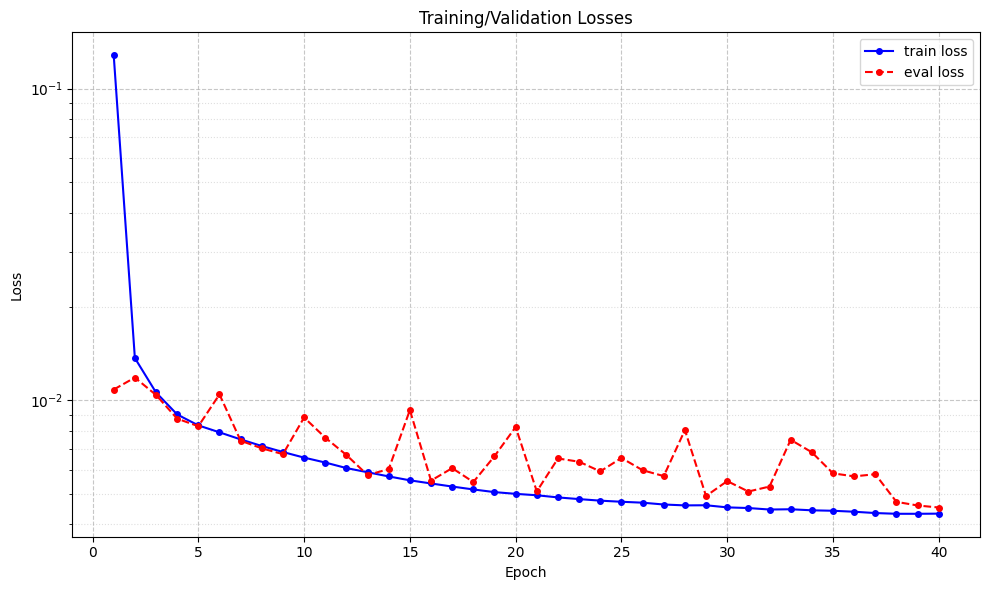

In [71]:
plot_training_losses(trainer)

# Evaluating on Synthetic Dataset (TEST)

### Load Data from synthetic dataset

In [72]:
# LOAD PARAMETERS
SYNTHETIC_PARAMS = {
    'unit': 'VG5',
    'test_set': '01',
    'anomaly_type': 'a',
    'set_type':'test_s01'
}

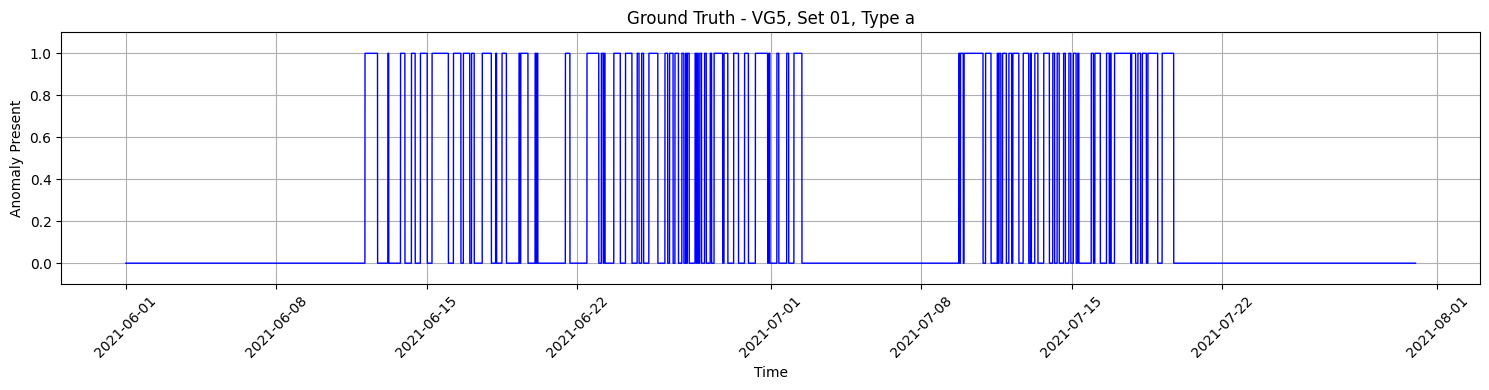

In [73]:
def obtain_ground_truth(dataset_root, unit="VG5", test_set="01", anomaly_type="a"):

    # Load anomaly data
    anomaly_file = Path(dataset_root) / "synthetic_anomalies" / f"{unit}_anomaly_{test_set}_type_{anomaly_type}.parquet"
    anomaly_data = pq.read_table(anomaly_file).to_pandas()
    ground_truth = anomaly_data['ground_truth']
    ground_truth_index = anomaly_data.index
    
    return ground_truth, ground_truth_index

def plot_ground_truth(ground_truth, ground_truth_index, unit, test_set, anomaly_type):
    """Plot ground truth data"""
    plt.figure(figsize=(15, 4))
    plt.plot(ground_truth_index, ground_truth, 'b-', linewidth=1)
    
    plt.title(f'Ground Truth - {unit}, Set {test_set}, Type {anomaly_type}')
    plt.ylim(-0.1, 1.1)
    plt.grid(True)
    plt.xlabel('Time')
    plt.ylabel('Anomaly Present')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

ground_truth, ground_truth_index = obtain_ground_truth(
    dataset_root,
    unit=SYNTHETIC_PARAMS['unit'],
    test_set=SYNTHETIC_PARAMS['test_set'],
    anomaly_type=SYNTHETIC_PARAMS['anomaly_type']
)

plot_ground_truth(
        ground_truth,
        ground_truth_index,
        unit=SYNTHETIC_PARAMS['unit'],
        test_set=SYNTHETIC_PARAMS['test_set'],
        anomaly_type=SYNTHETIC_PARAMS['anomaly_type']
    )

In [74]:
# Load only synthetic test data (no training data needed)
rds_u5_synth = RawDataset(dataset_root, "VG5", load_synthetic=True, load_training=False)

# Process synthetic datasets
rds_u5_synth_processed = preprocess_hydraulic_data(
    rds_u5_synth, set_type=SYNTHETIC_PARAMS['set_type'], operating_conditions=operating_conditions_set  # set at the top
)

control_df_test = rds_u5_synth_processed['control_signals']
sensors_df_test = rds_u5_synth_processed['sensor_signals']

sensors_voltage_current_test = sensors_df_test[0]
sensors_stator_temperature_test = sensors_df_test[1]
sensors_cooling_system_test = sensors_df_test[2]
sensors_heat_exchanger_test = sensors_df_test[3]
sensors_other_test = sensors_df_test[4]

# Print the number of features in each sensor group
print("\nNumber of features in each sensor group:")
for i, sensor_group in enumerate(['Voltage/Current', 'Stator Temperature', 
                                'Cooling System', 'Heat Exchanger', 'Other']):
    print(f"{sensor_group}: {len(sensors_df_test[i].columns)} features")

# Now you can safely delete if needed
del rds_u5_synth
del rds_u5_synth_processed


Number of features in each sensor group:
Voltage/Current: 14 features
Stator Temperature: 30 features
Cooling System: 12 features
Heat Exchanger: 9 features
Other: 10 features


## [CHANGE] Start evaluating synthetic dataset

In [75]:
SELECTED_SENSOR_GROUP_TEST = sensors_stator_temperature_test

In [76]:
def evaluate_and_visualize(model, control_df_test, sensor_df_test, ground_truth, ground_truth_index):
    model.eval()

    # Create test dataset and loader
    test_dataset = SlidingWindowDataset(
        control_df_test,
        sensor_df_test,
        window=DEFAULT_PARAMS['window']
    )
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    predictions = []
    actuals = []
    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            pred = model(X)
            predictions.append(pred.cpu().numpy())
            actuals.append(y.numpy())
    
    y_pred = np.concatenate(predictions, axis=0)
    y_test = np.concatenate(actuals, axis=0)

    # Get the time index
    time_index = sensor_df_test.index[:len(y_test)]

    n_sensors = y_test.shape[1]
    for sensor_idx in range(n_sensors):
        # Create figure with 3 subplots
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), height_ratios=[2, 1, 1])
        fig.suptitle(f'Sensor {sensor_idx + 1} Predictions vs Actual', y=1.02)
        
        # Plot 1: Predictions vs Actual using actual time index
        ax1.plot(time_index, y_test[:, sensor_idx], label='Actual', alpha=0.7)
        ax1.plot(time_index, y_pred[:, sensor_idx], label='Predicted', alpha=0.7)
        ax1.set_title(f'Predictions and Actual Values')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Value')
        ax1.legend()
        ax1.grid(True)
        
        # Plot 2: Ground Truth
        ax2.plot(ground_truth_index, ground_truth, 'r-')
        ax2.set_ylim(-0.1, 1.1)
        ax2.set_title('Ground Truth Anomalies')
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Anomaly Present')
        ax2.grid(True)
        
        # Plot 3: Difference between predicted and actual
        difference = y_pred[:, sensor_idx] - y_test[:, sensor_idx]
        ax3.plot(time_index, difference, 'g-', label='Prediction Error')
        ax3.axhline(y=0, color='r', linestyle='--', alpha=0.3)  # Add zero line for reference
        ax3.set_title('Prediction Error (Predicted - Actual)')
        ax3.set_xlabel('Time')
        ax3.set_ylabel('Error')
        ax3.grid(True)
        ax3.legend()
        
        # Calculate metrics for this sensor
        mse = mean_squared_error(y_test[:, sensor_idx], y_pred[:, sensor_idx])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test[:, sensor_idx], y_pred[:, sensor_idx])
        
        # Add metrics to plot
        textstr = f'RMSE: {rmse:.4f}\nMAE: {mae:.4f}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=9,
                verticalalignment='top', bbox=props)
        
        plt.tight_layout()
        plt.show()
    
    # Print overall metrics
    print("\nOverall Metrics:")
    print(f"Overall RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
    print(f"Overall MAE: {mean_absolute_error(y_test, y_pred):.4f}")
    
    return y_pred, y_test

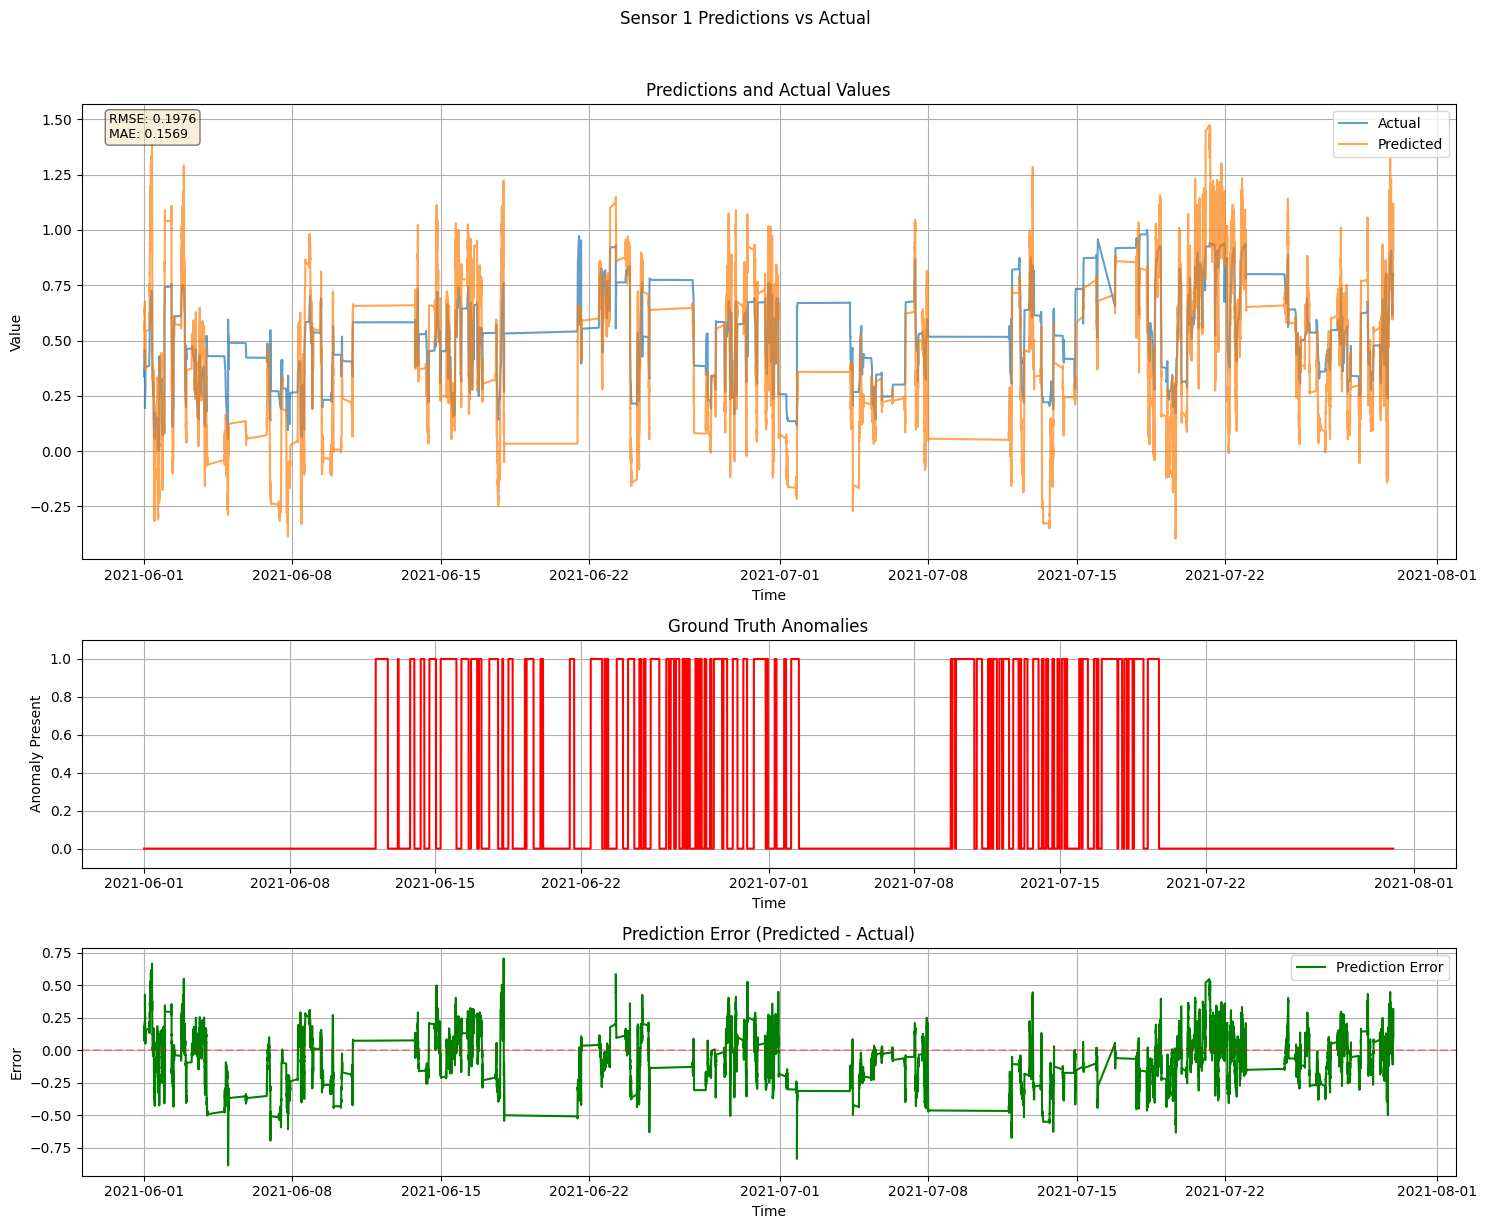

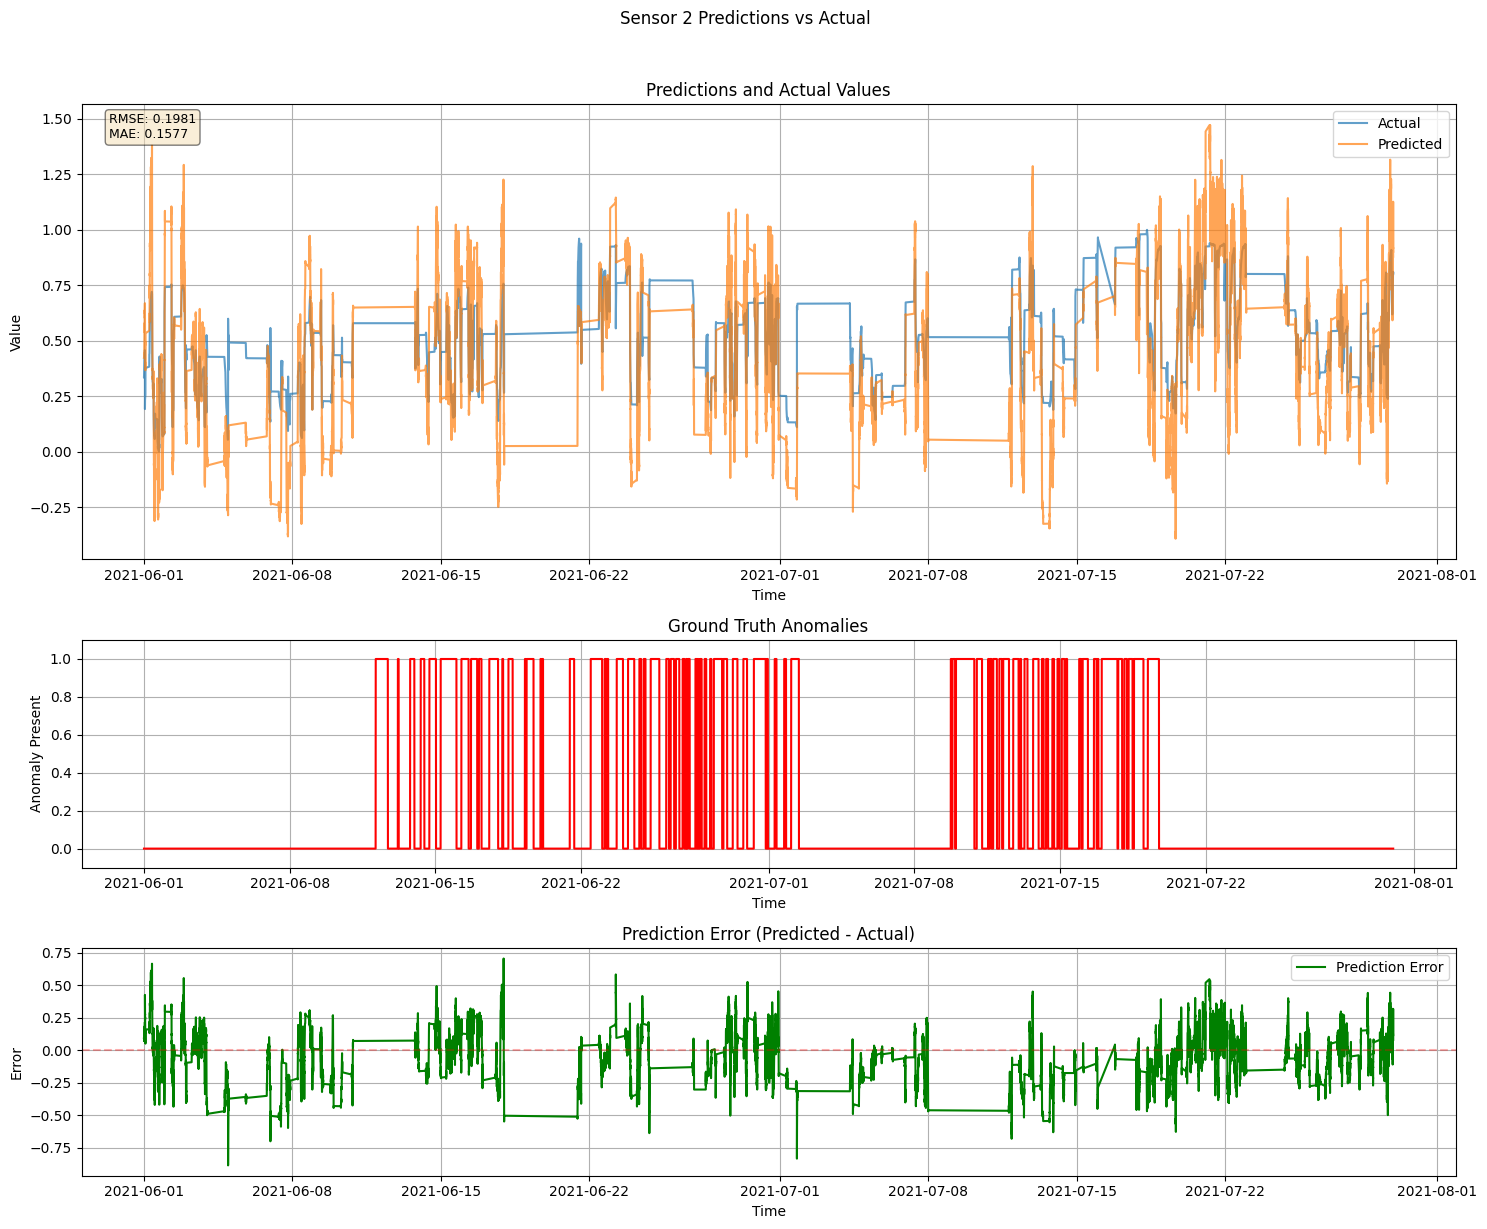

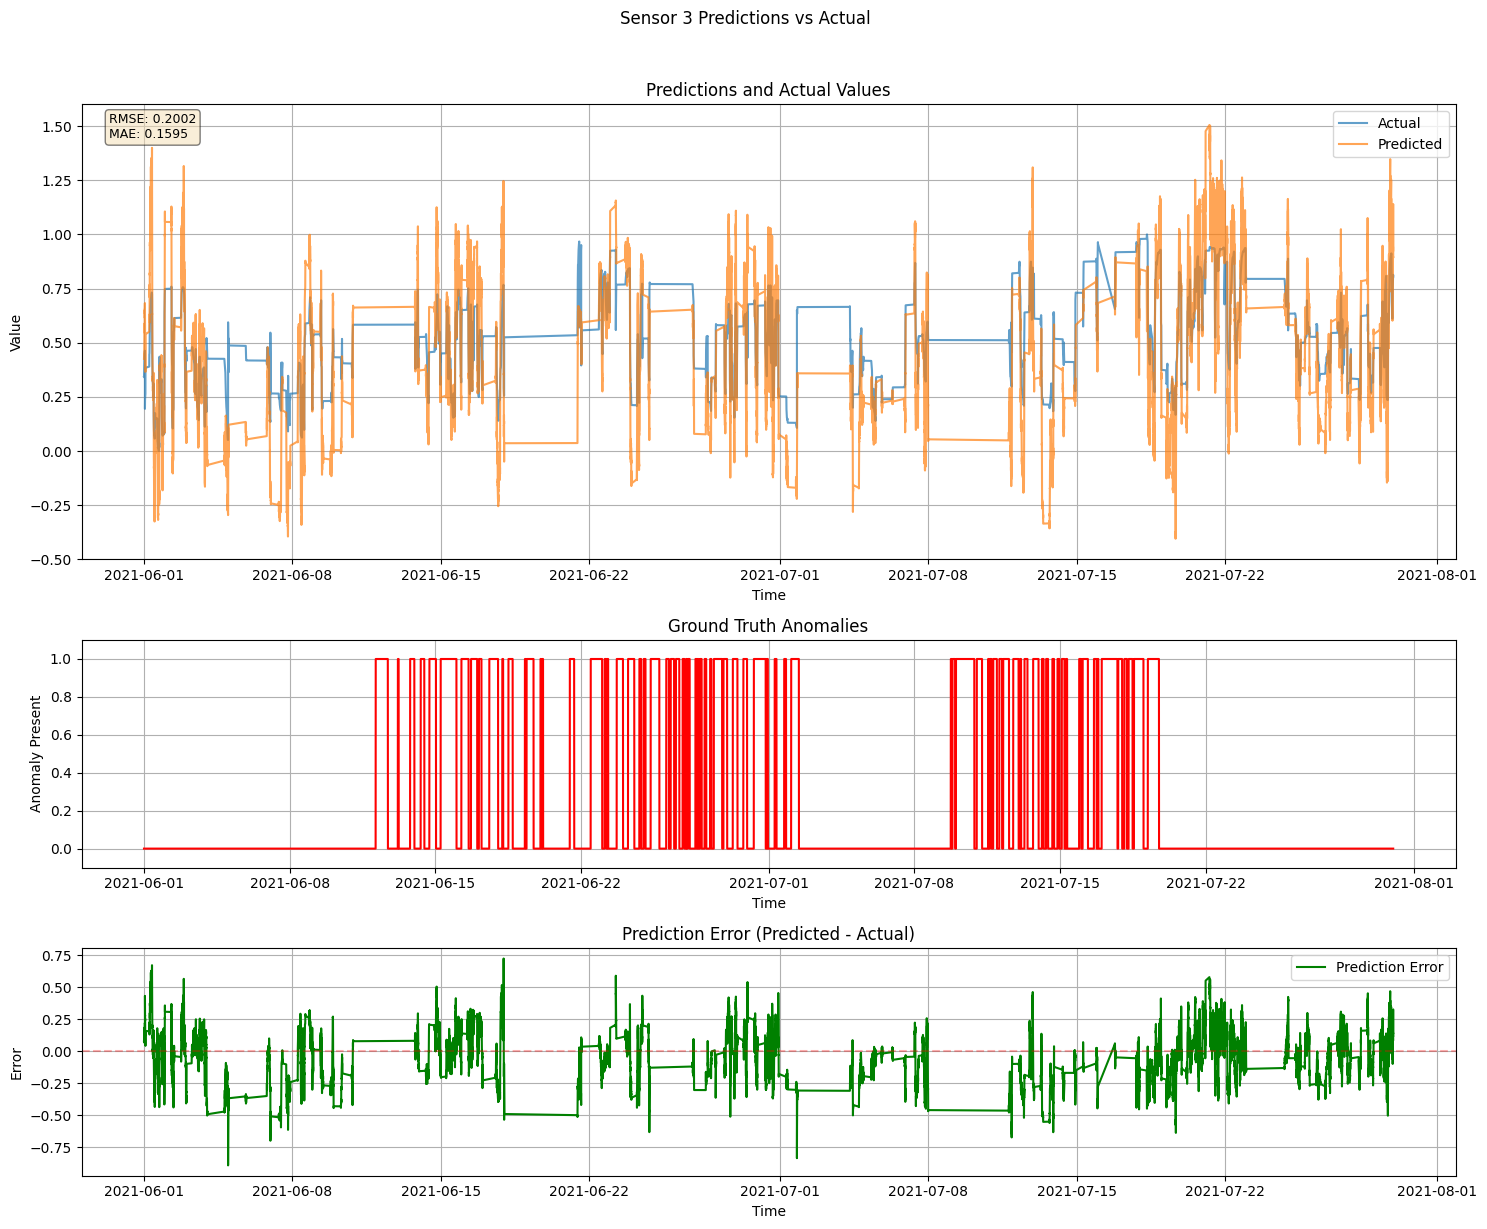

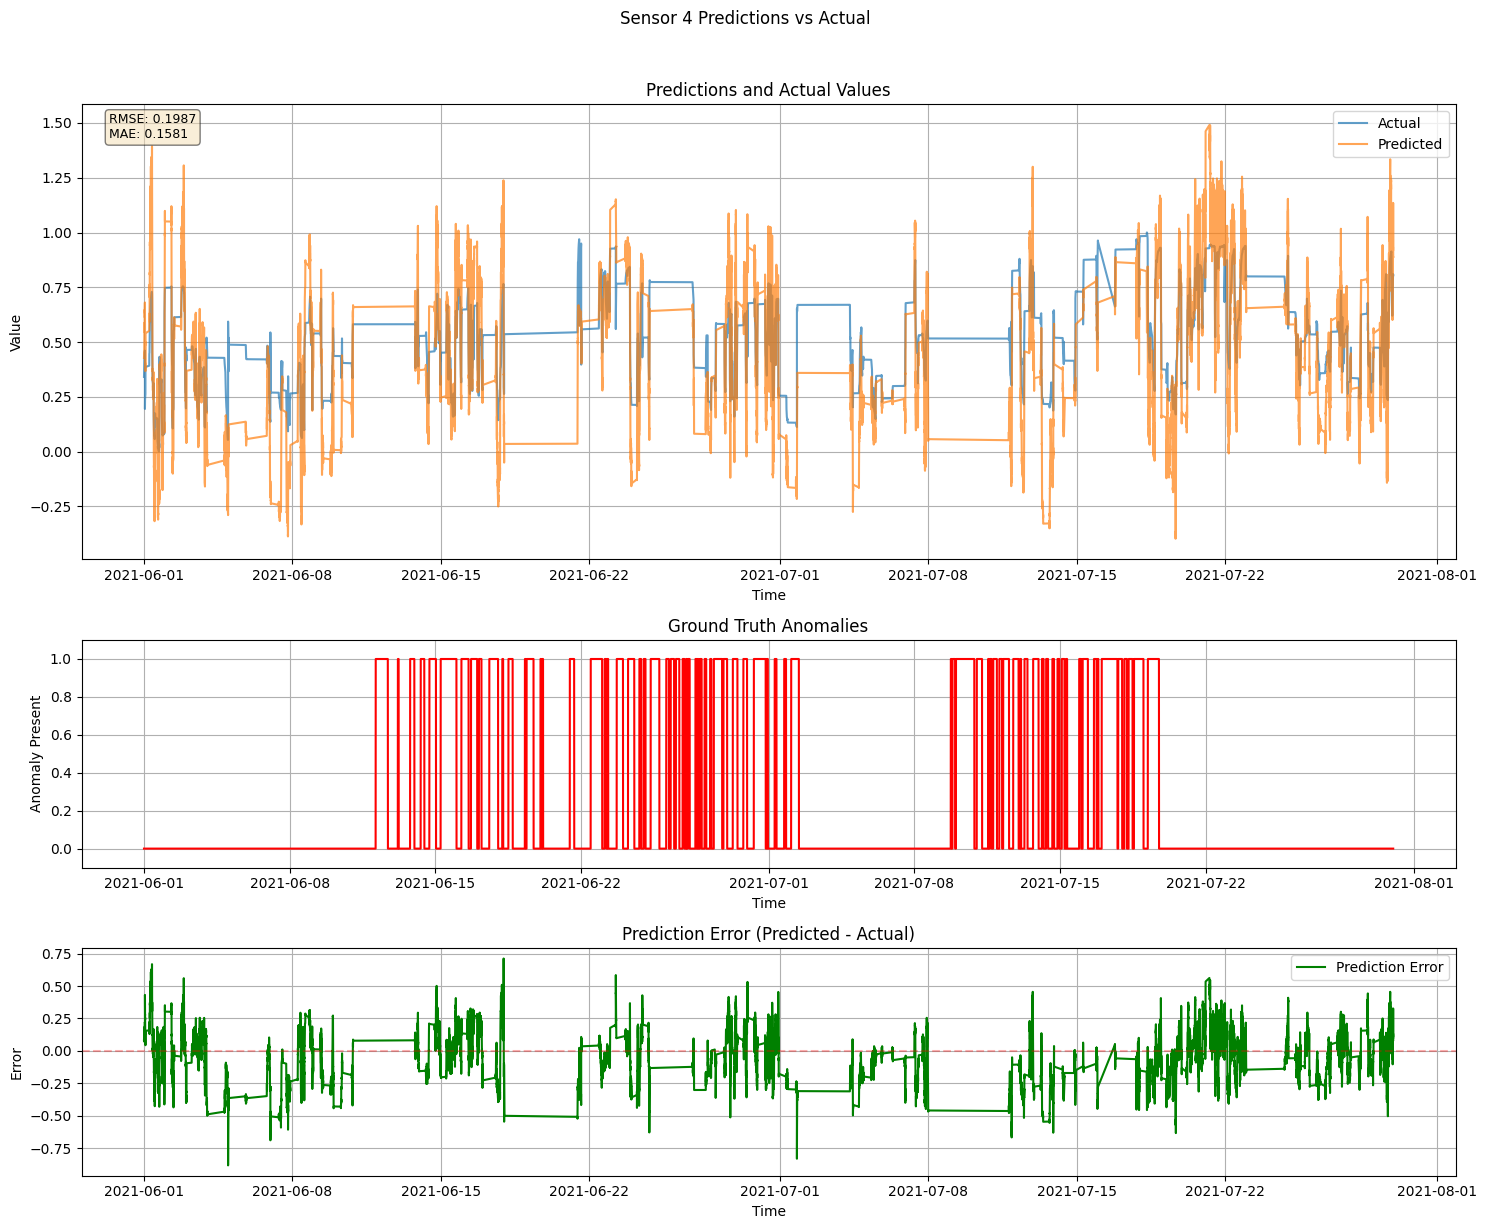

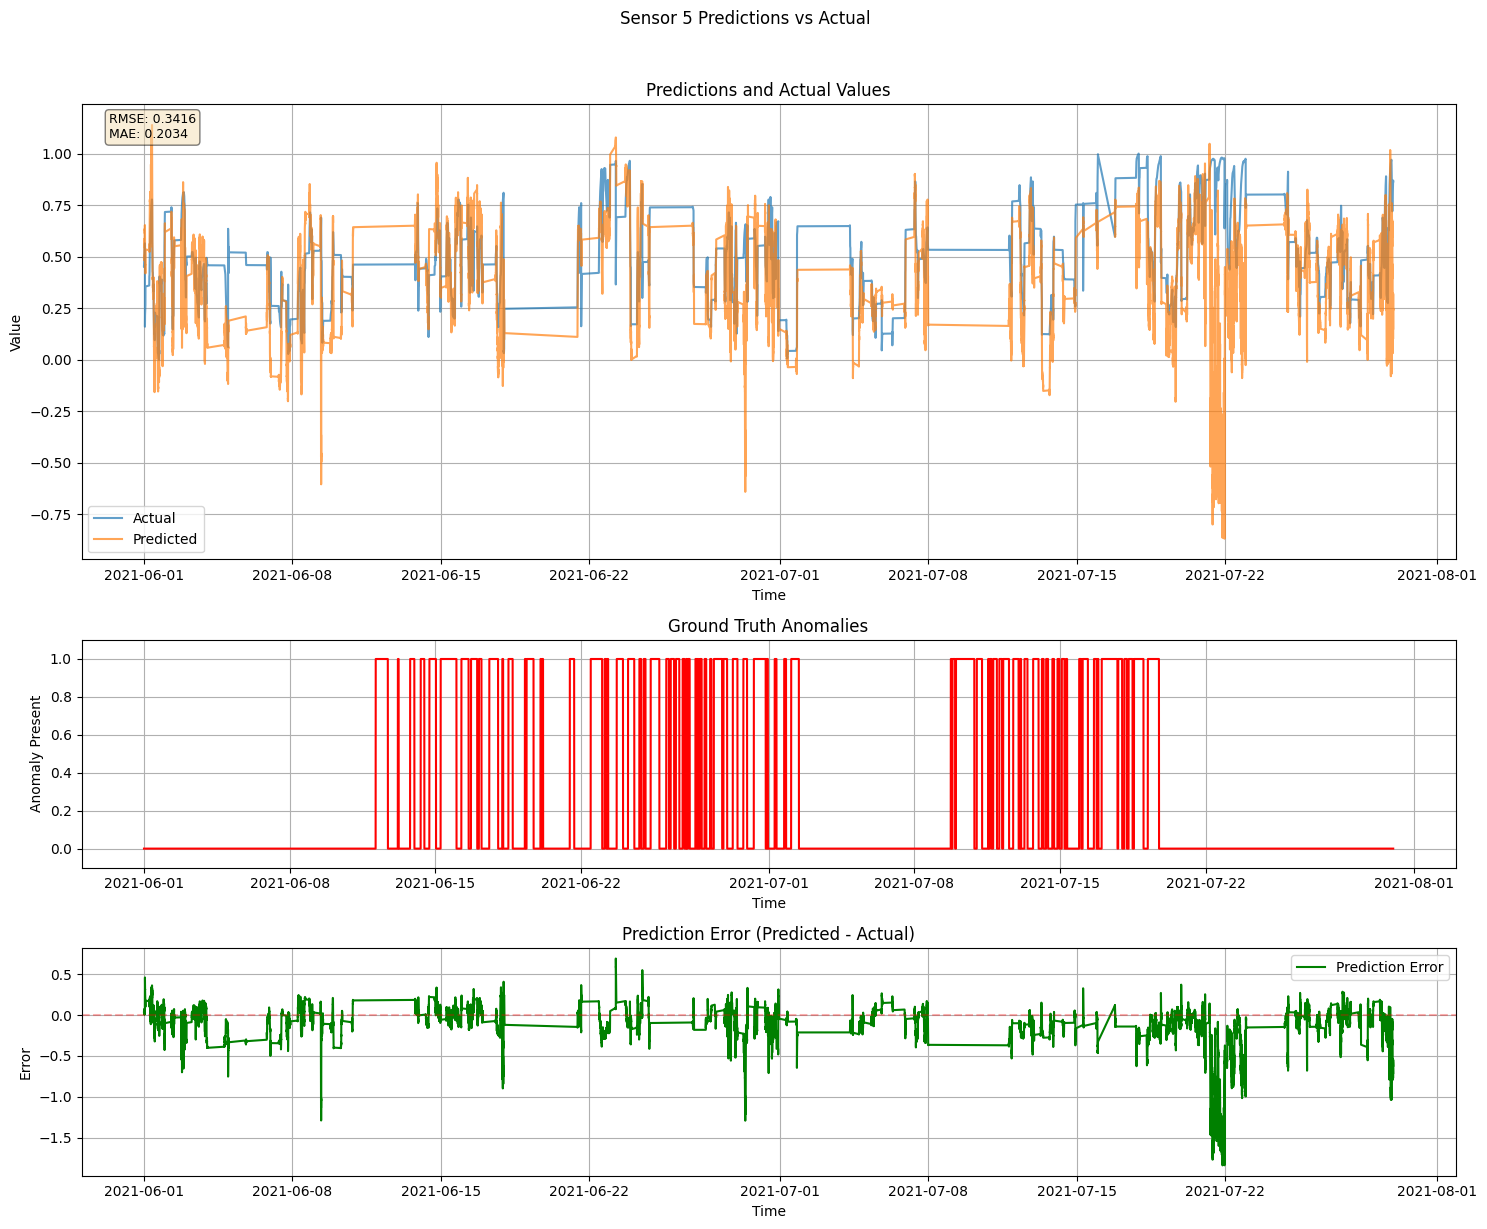

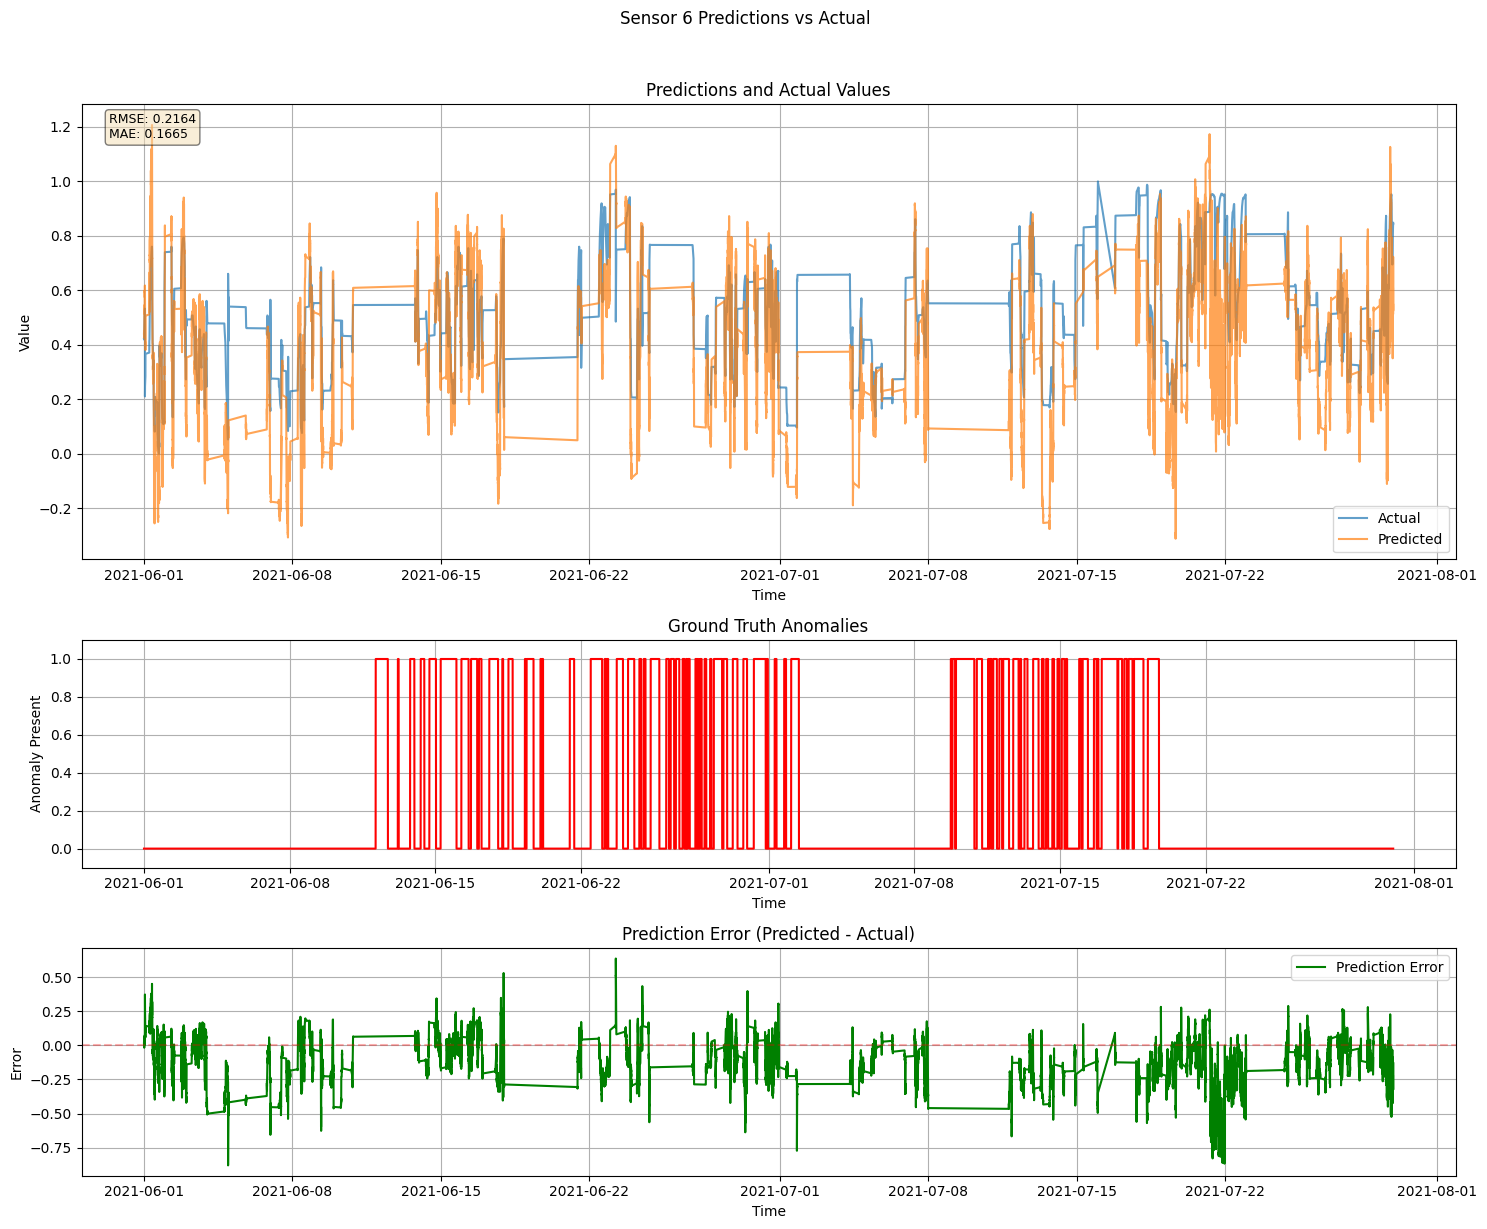

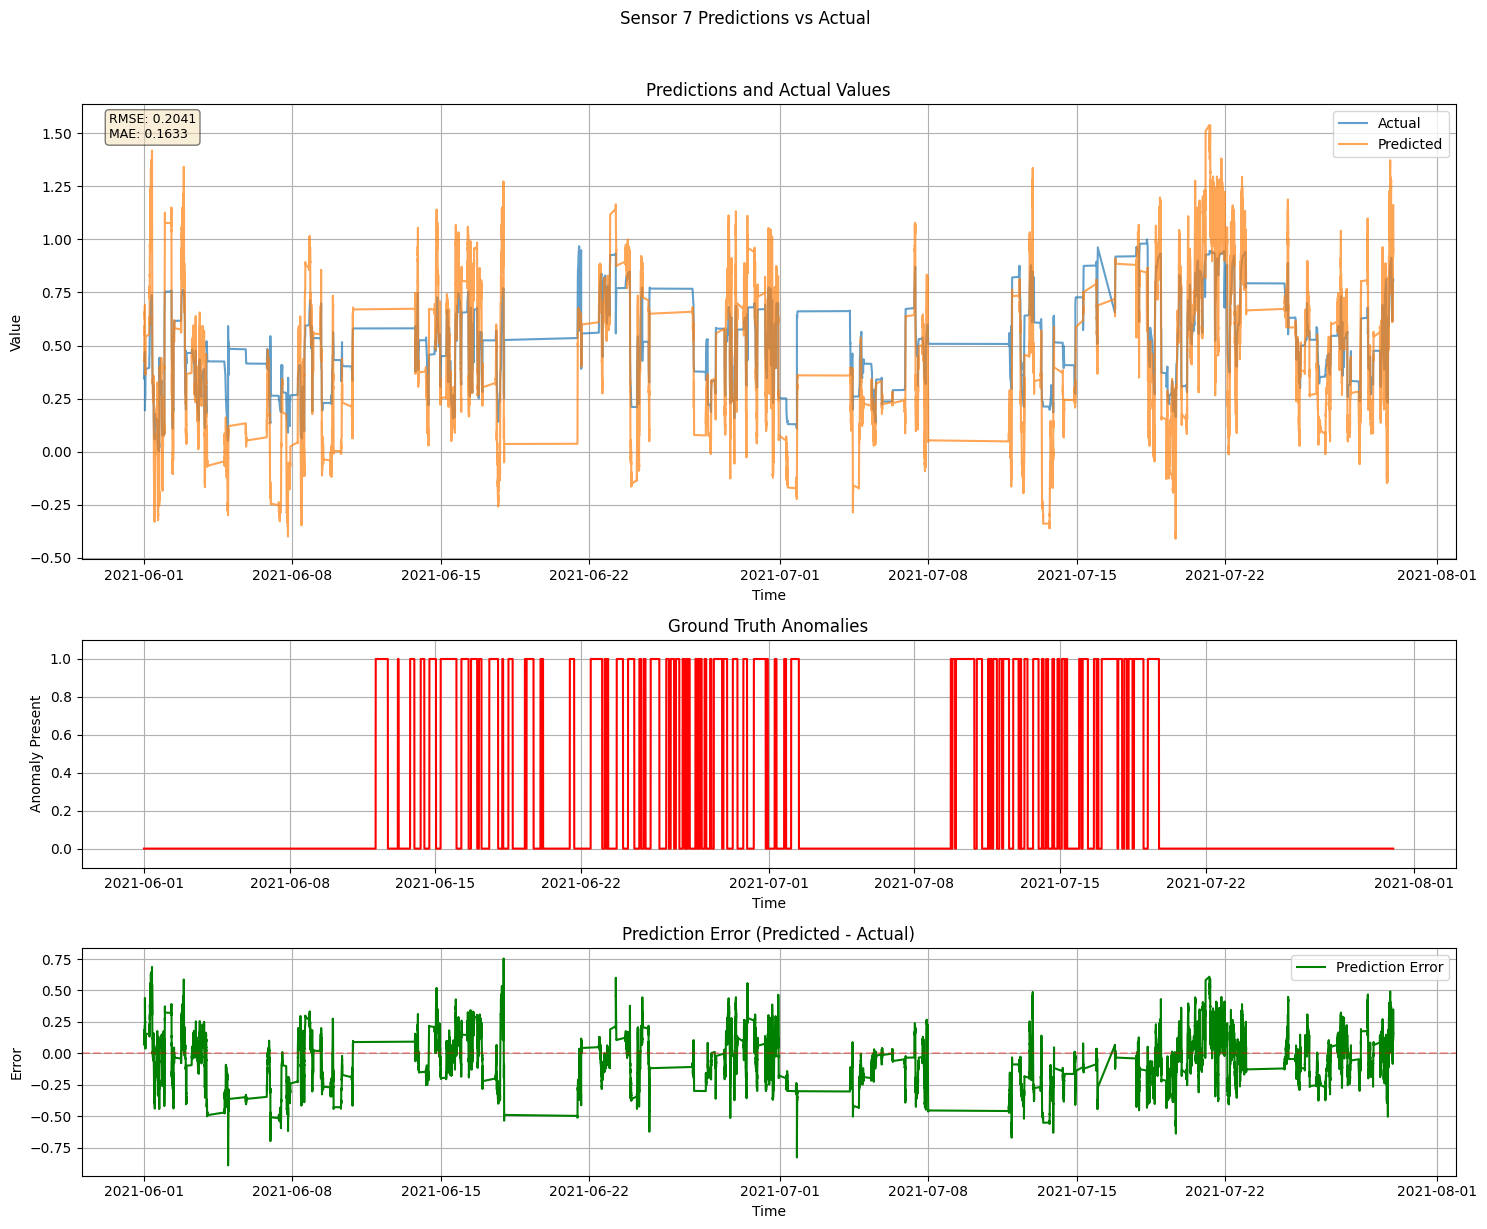

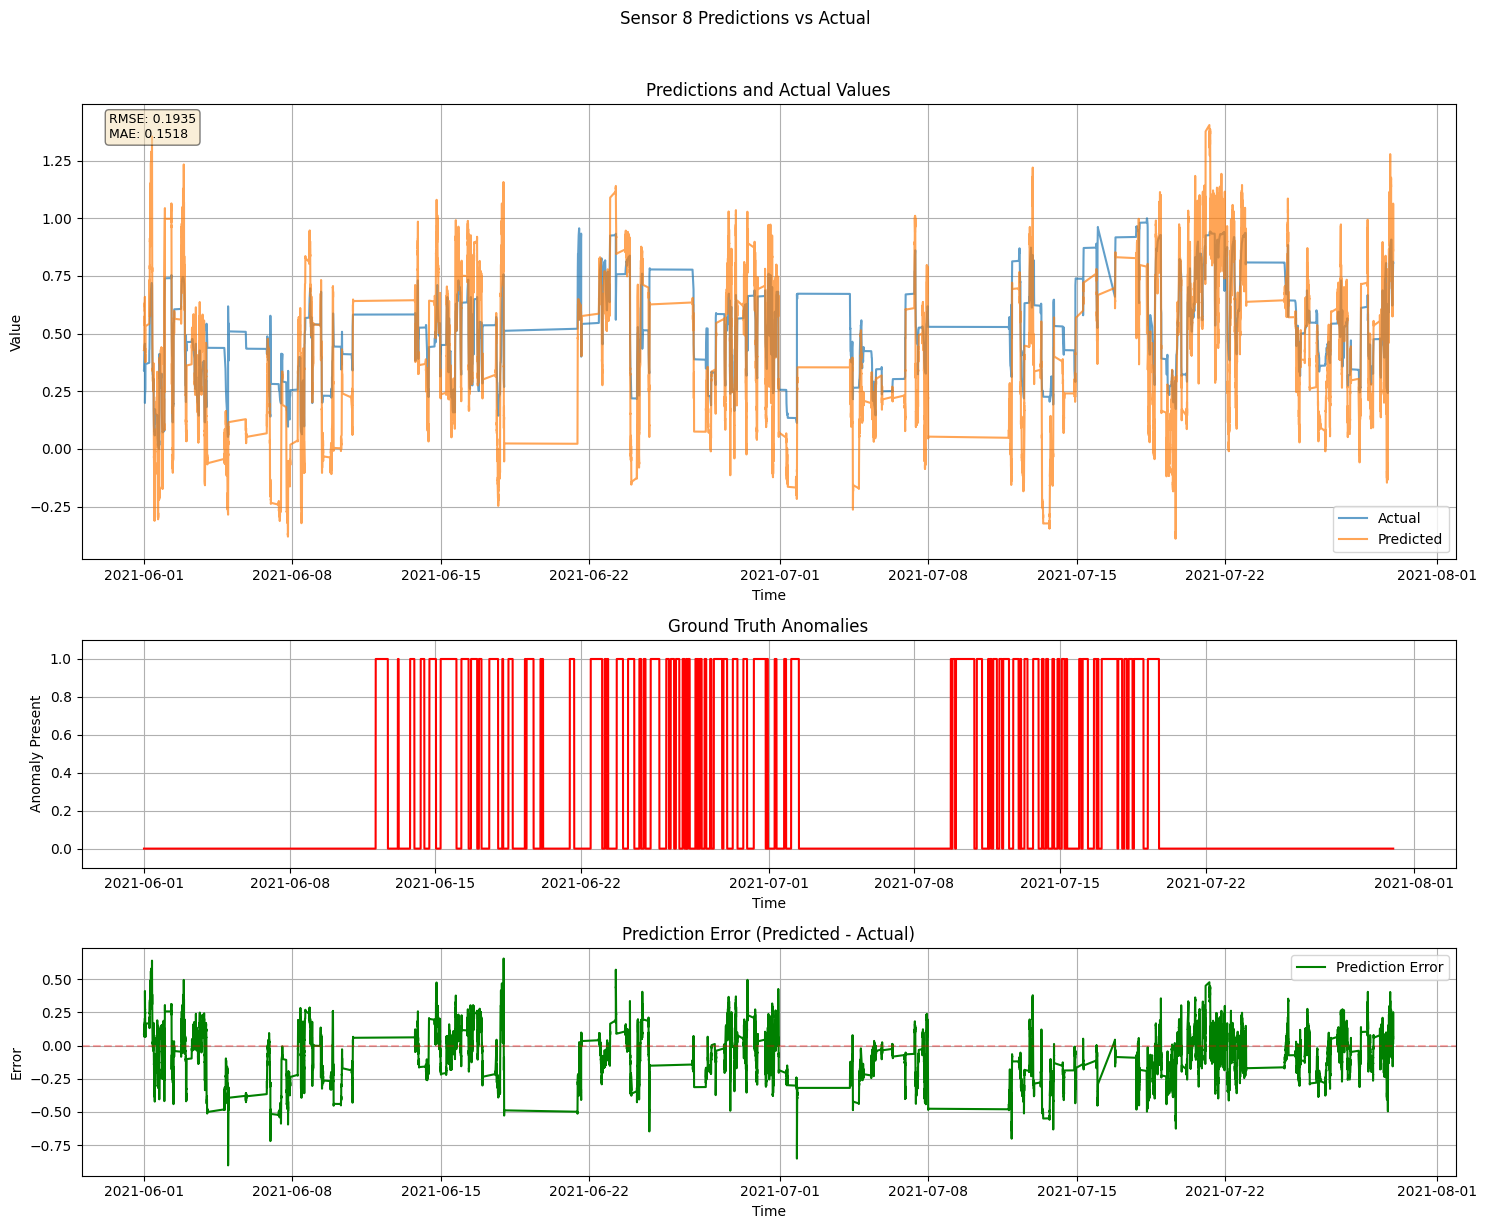

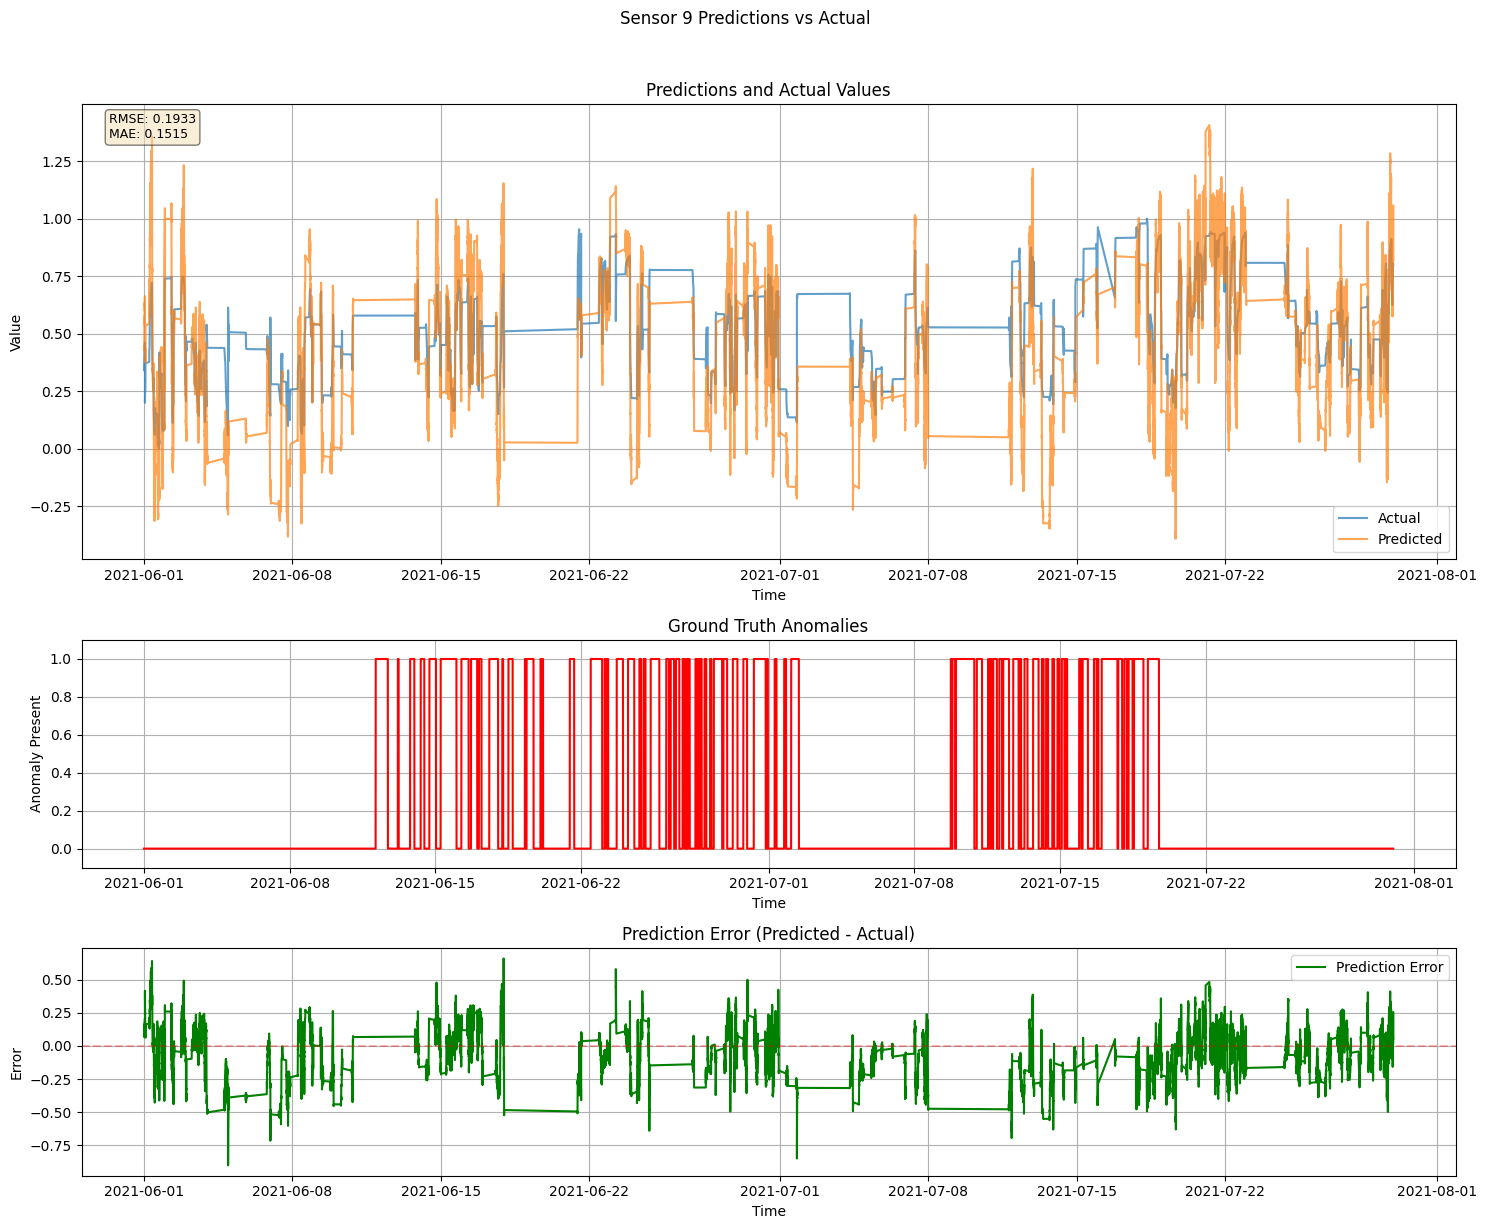

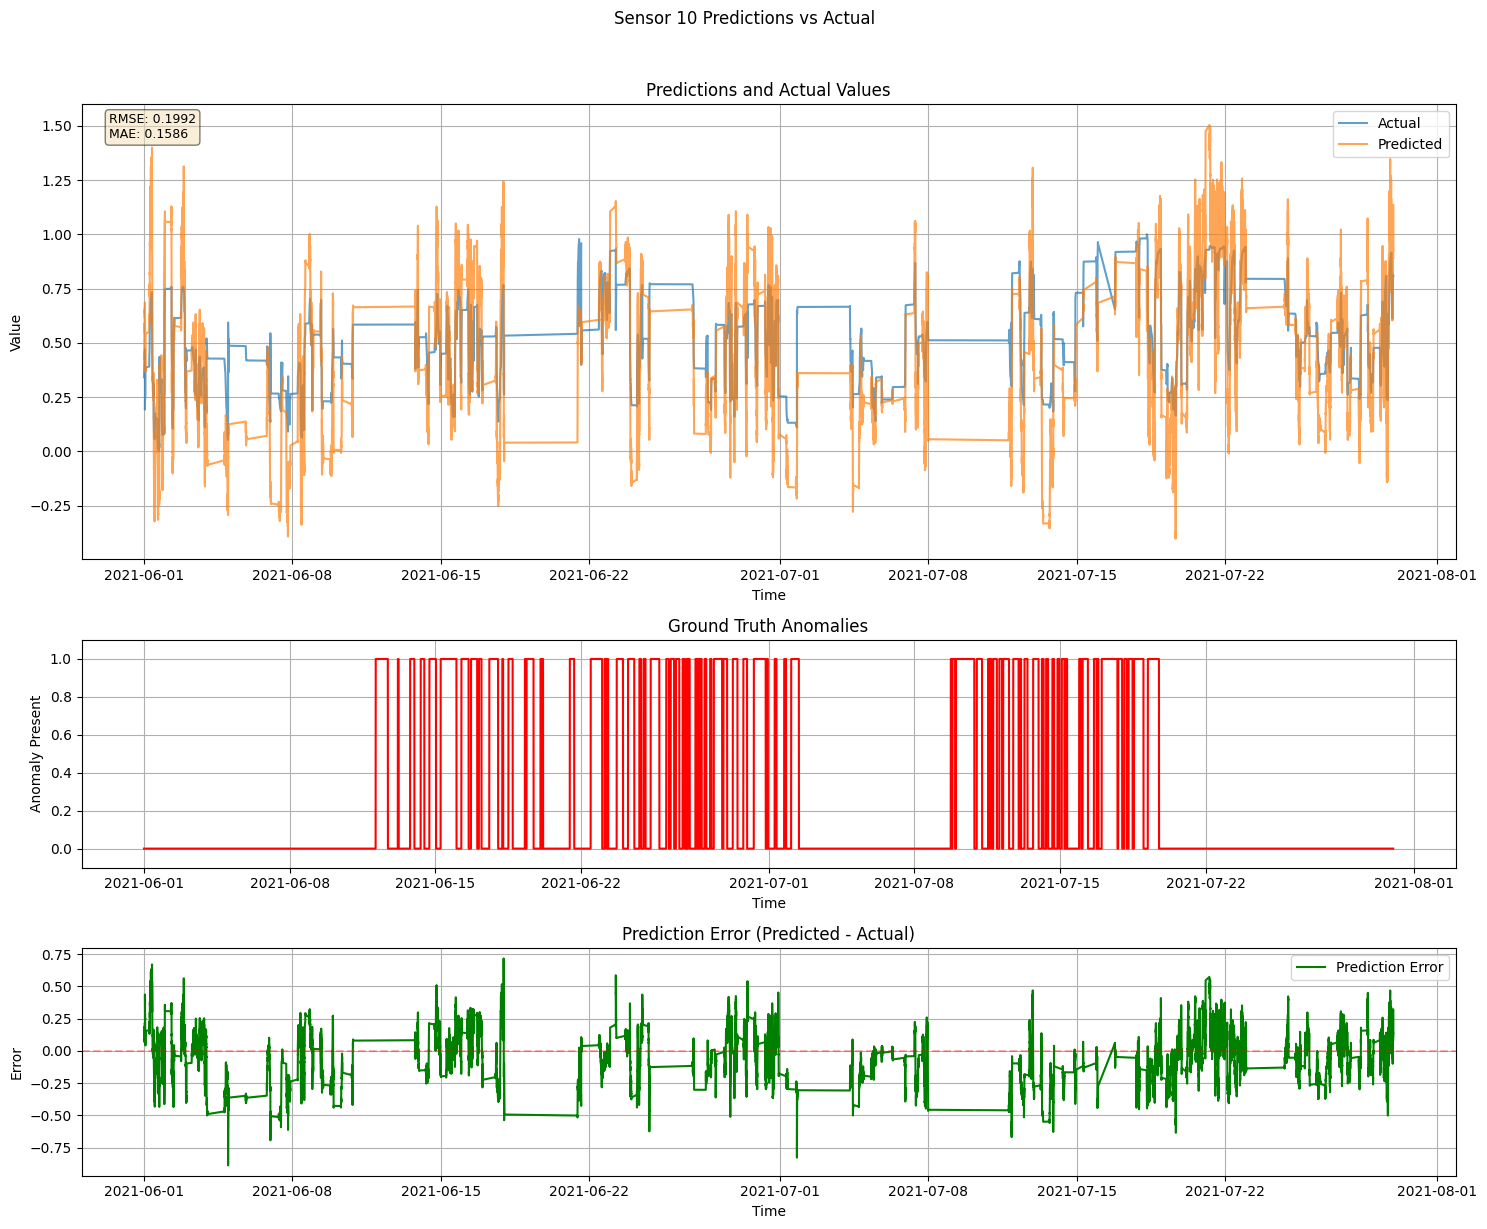

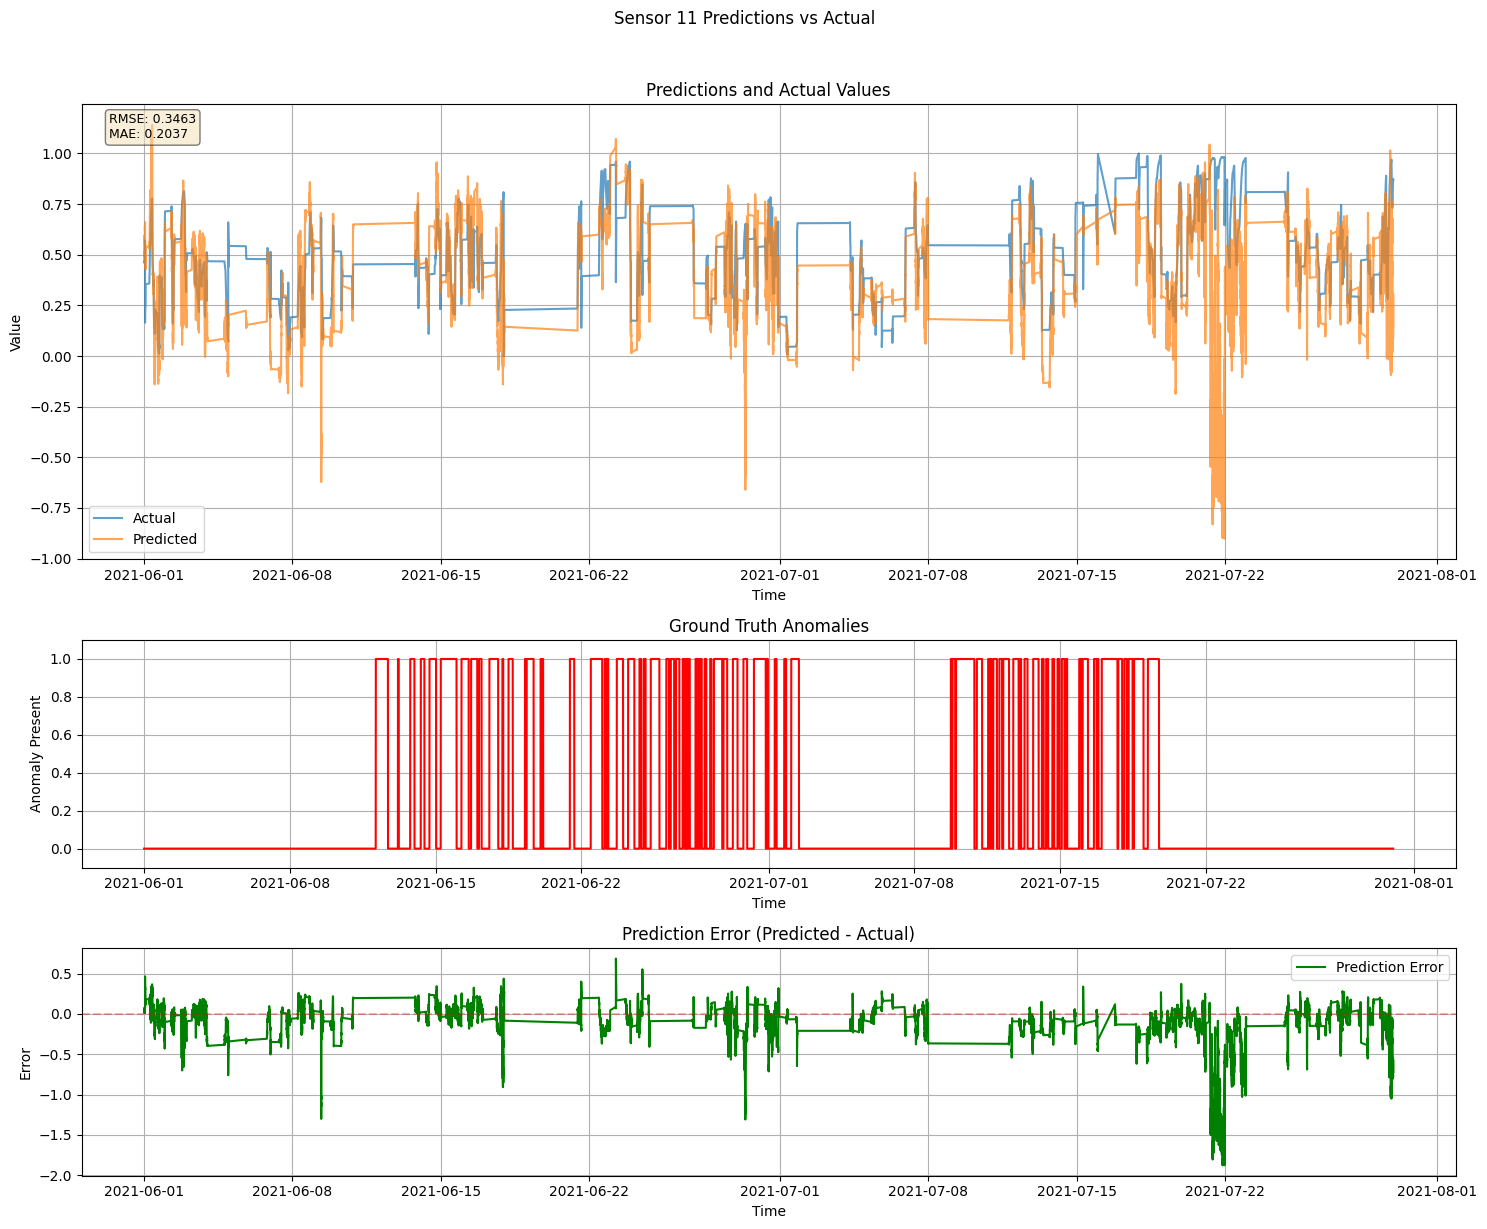

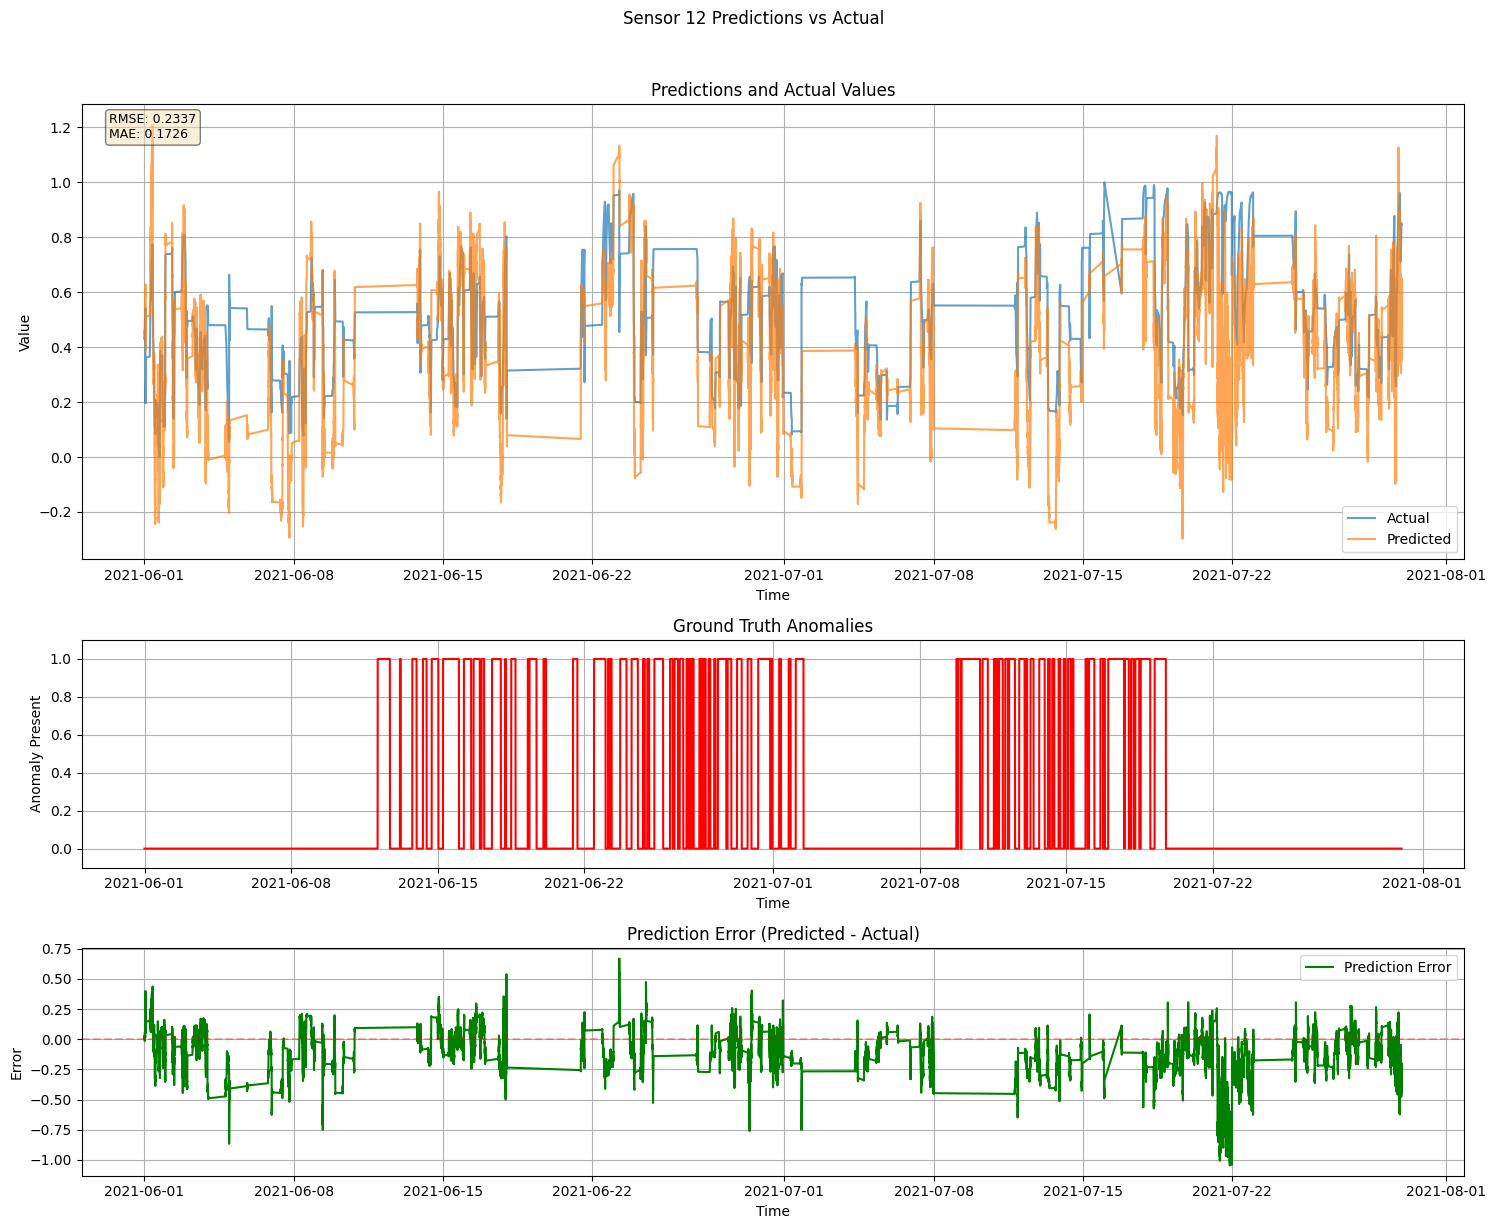

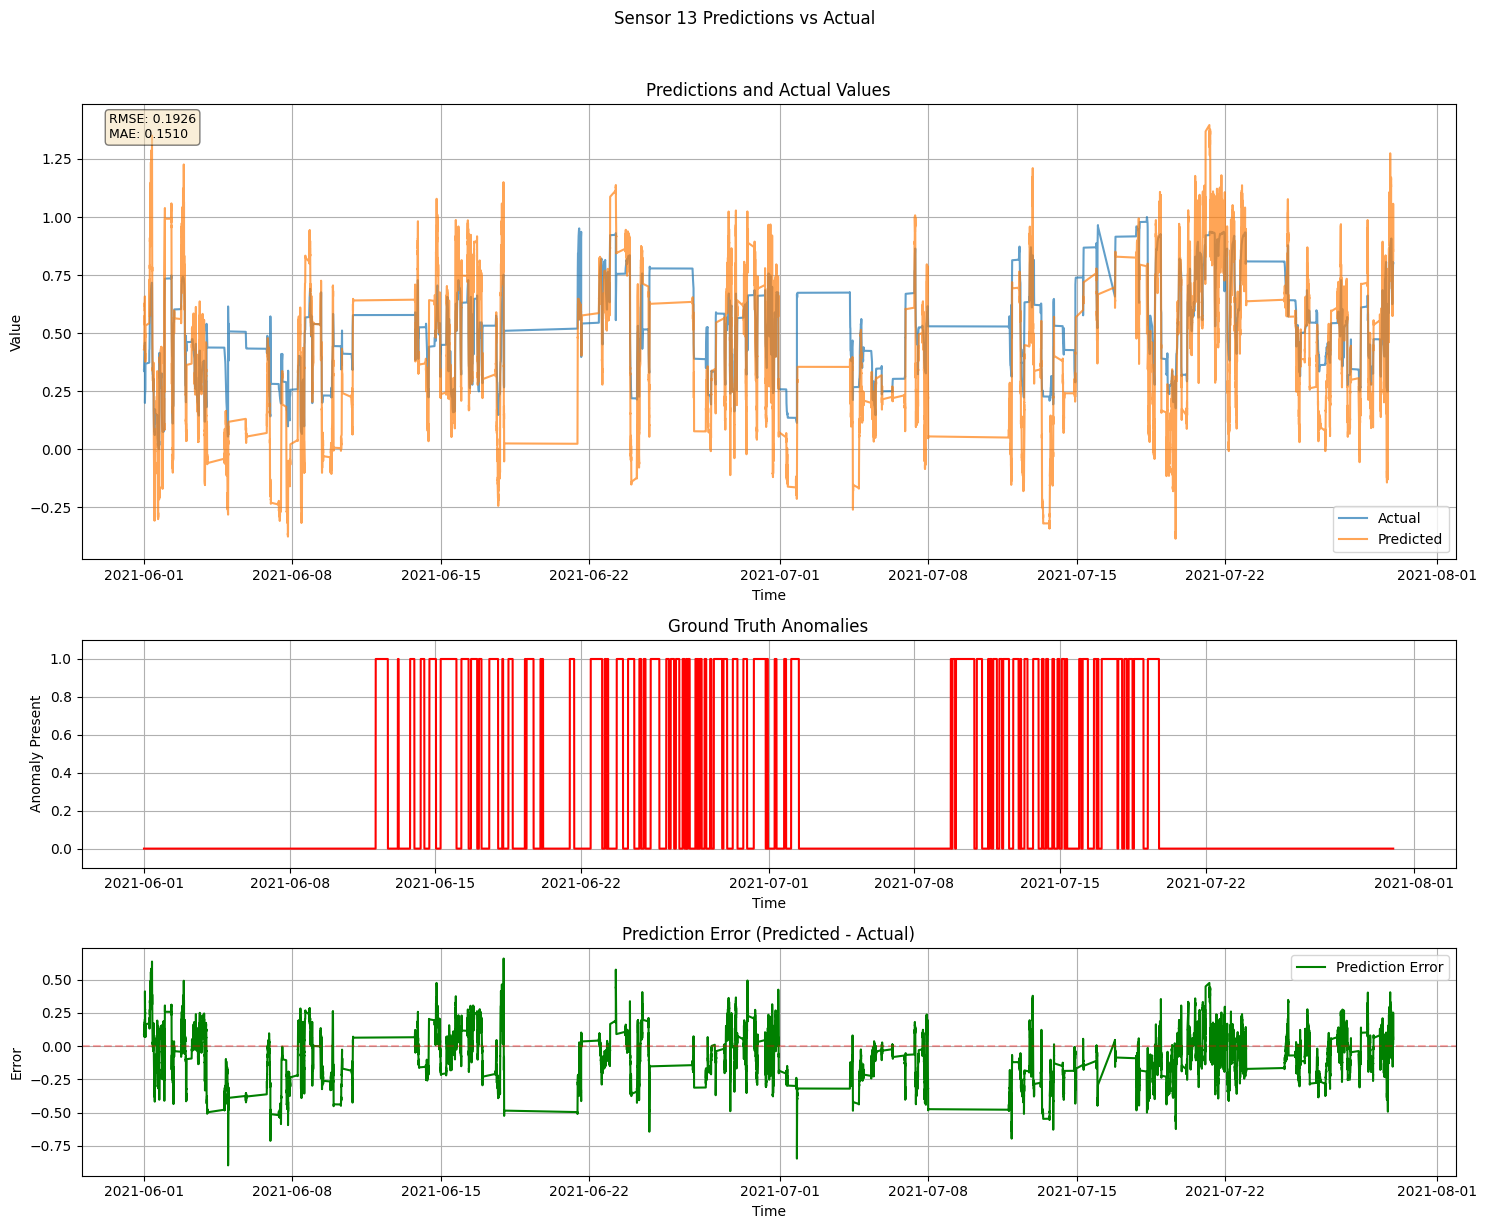

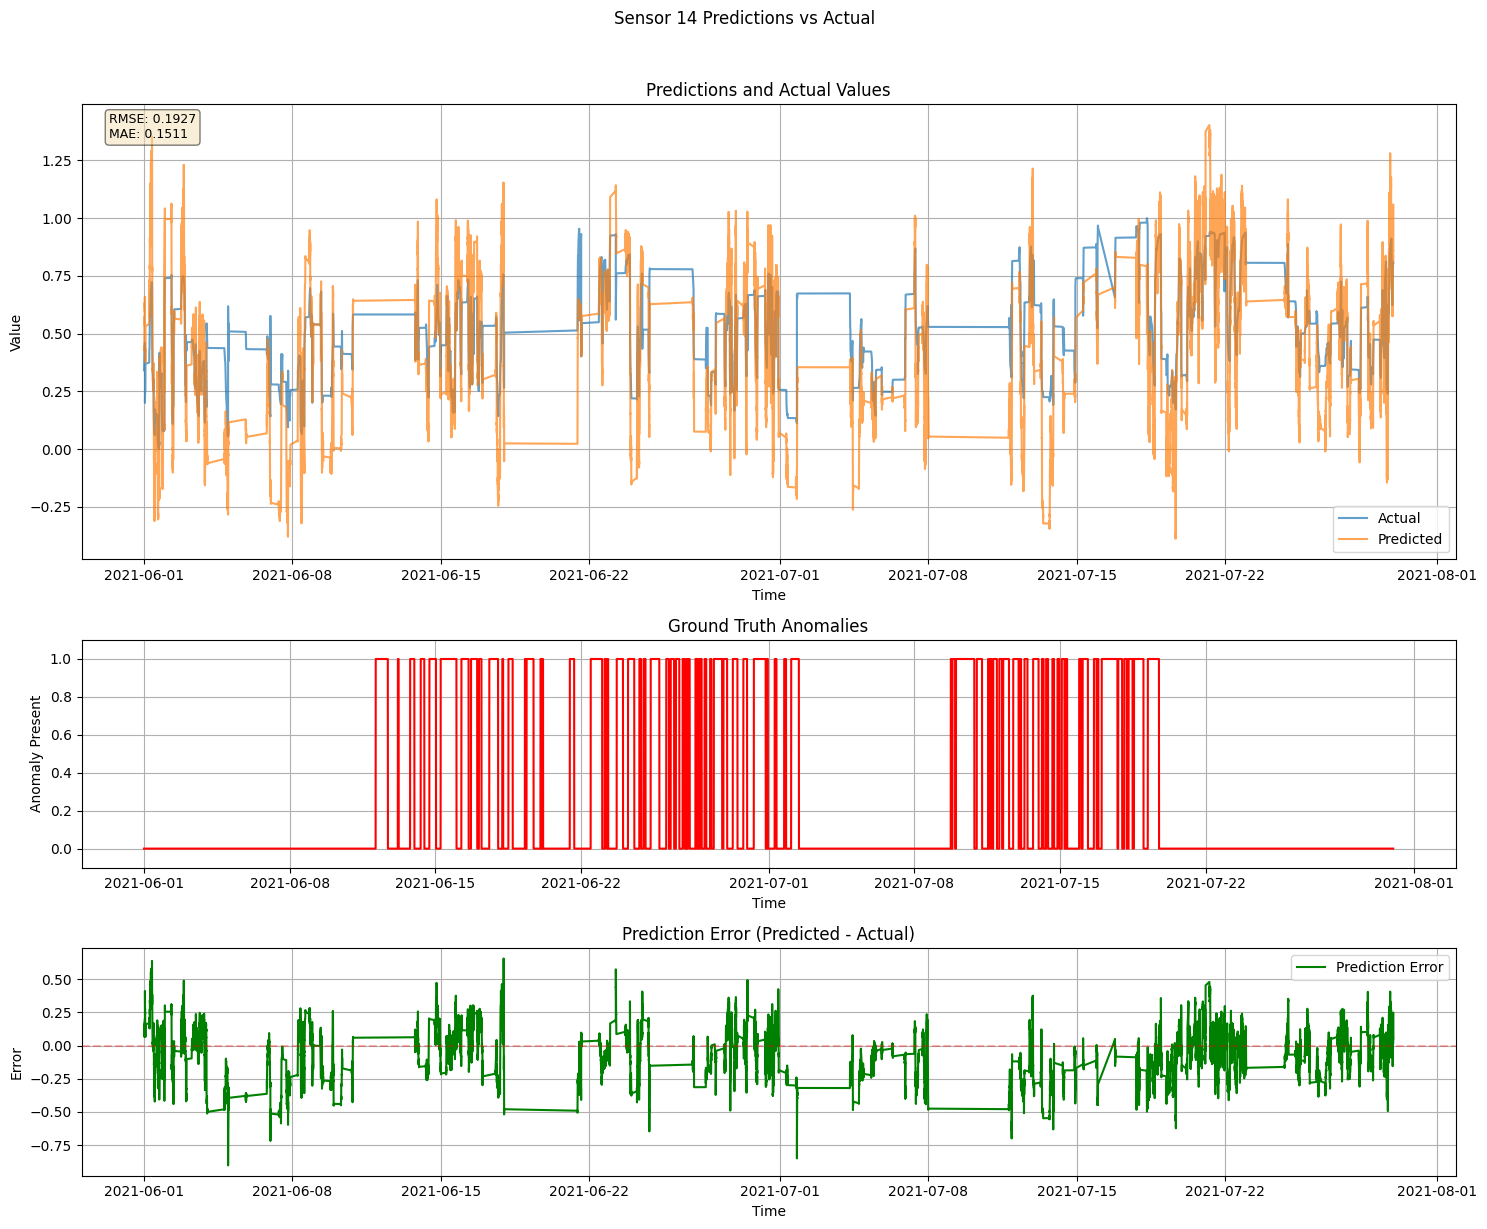

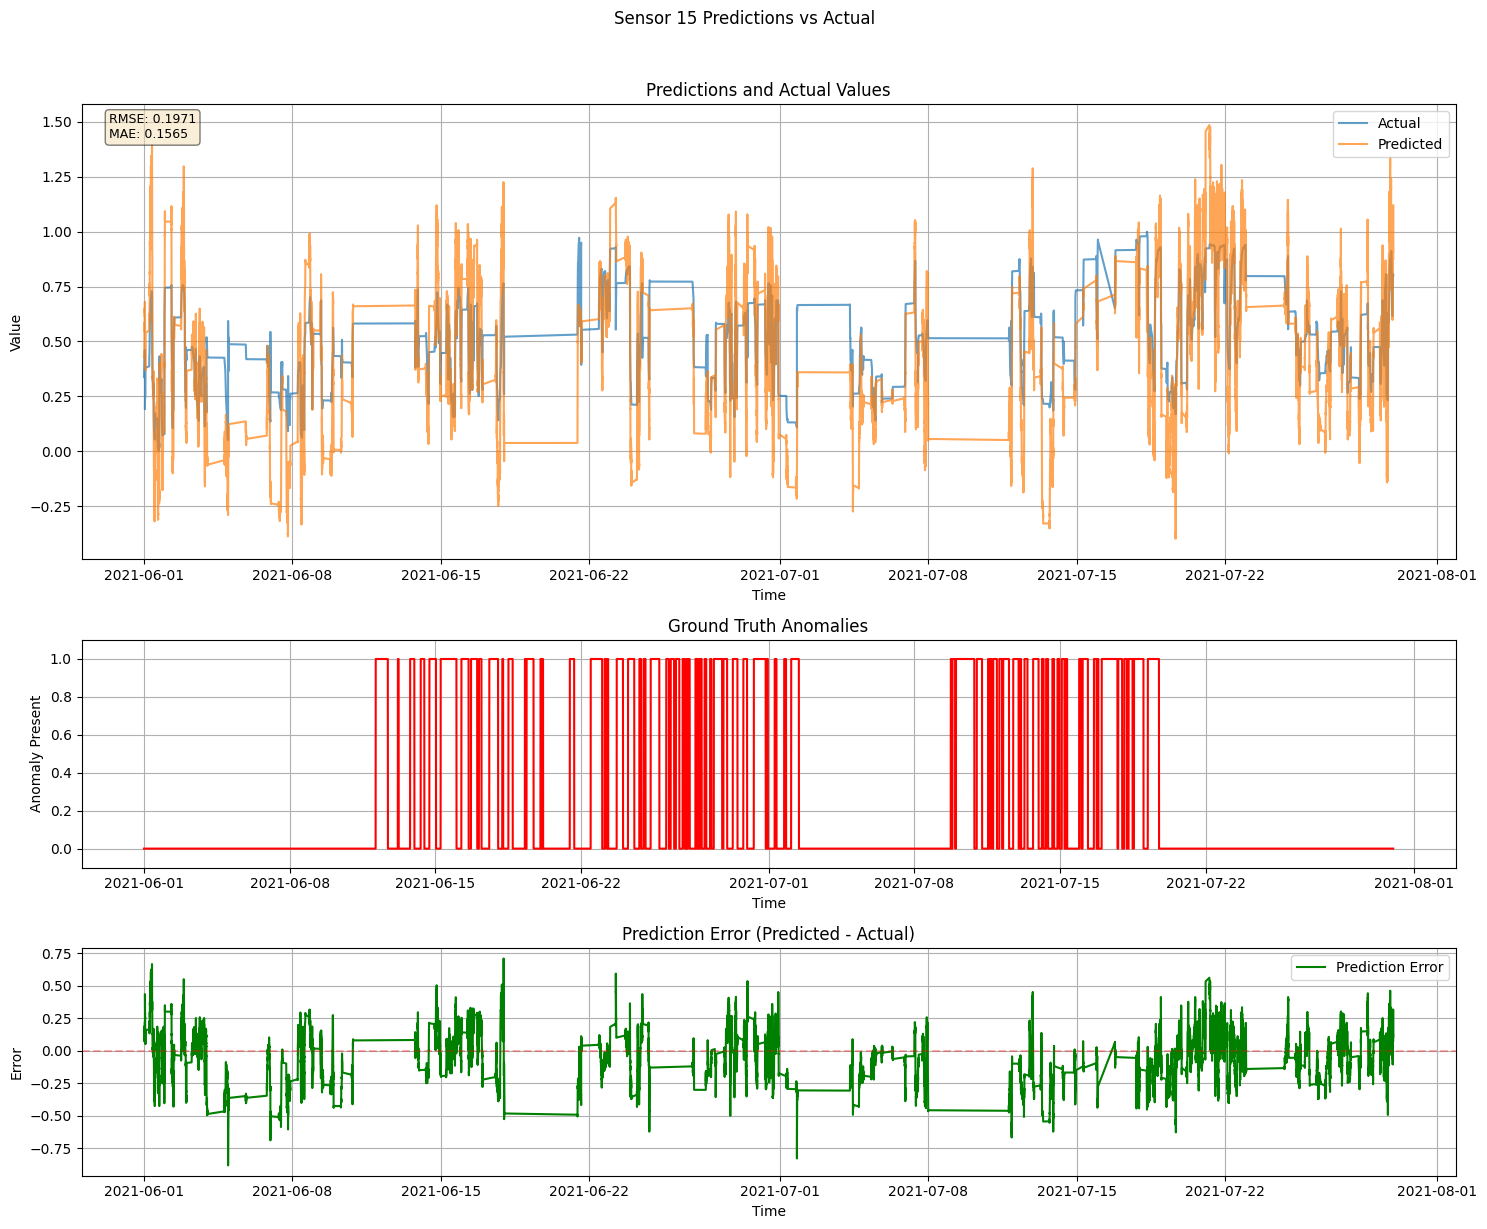

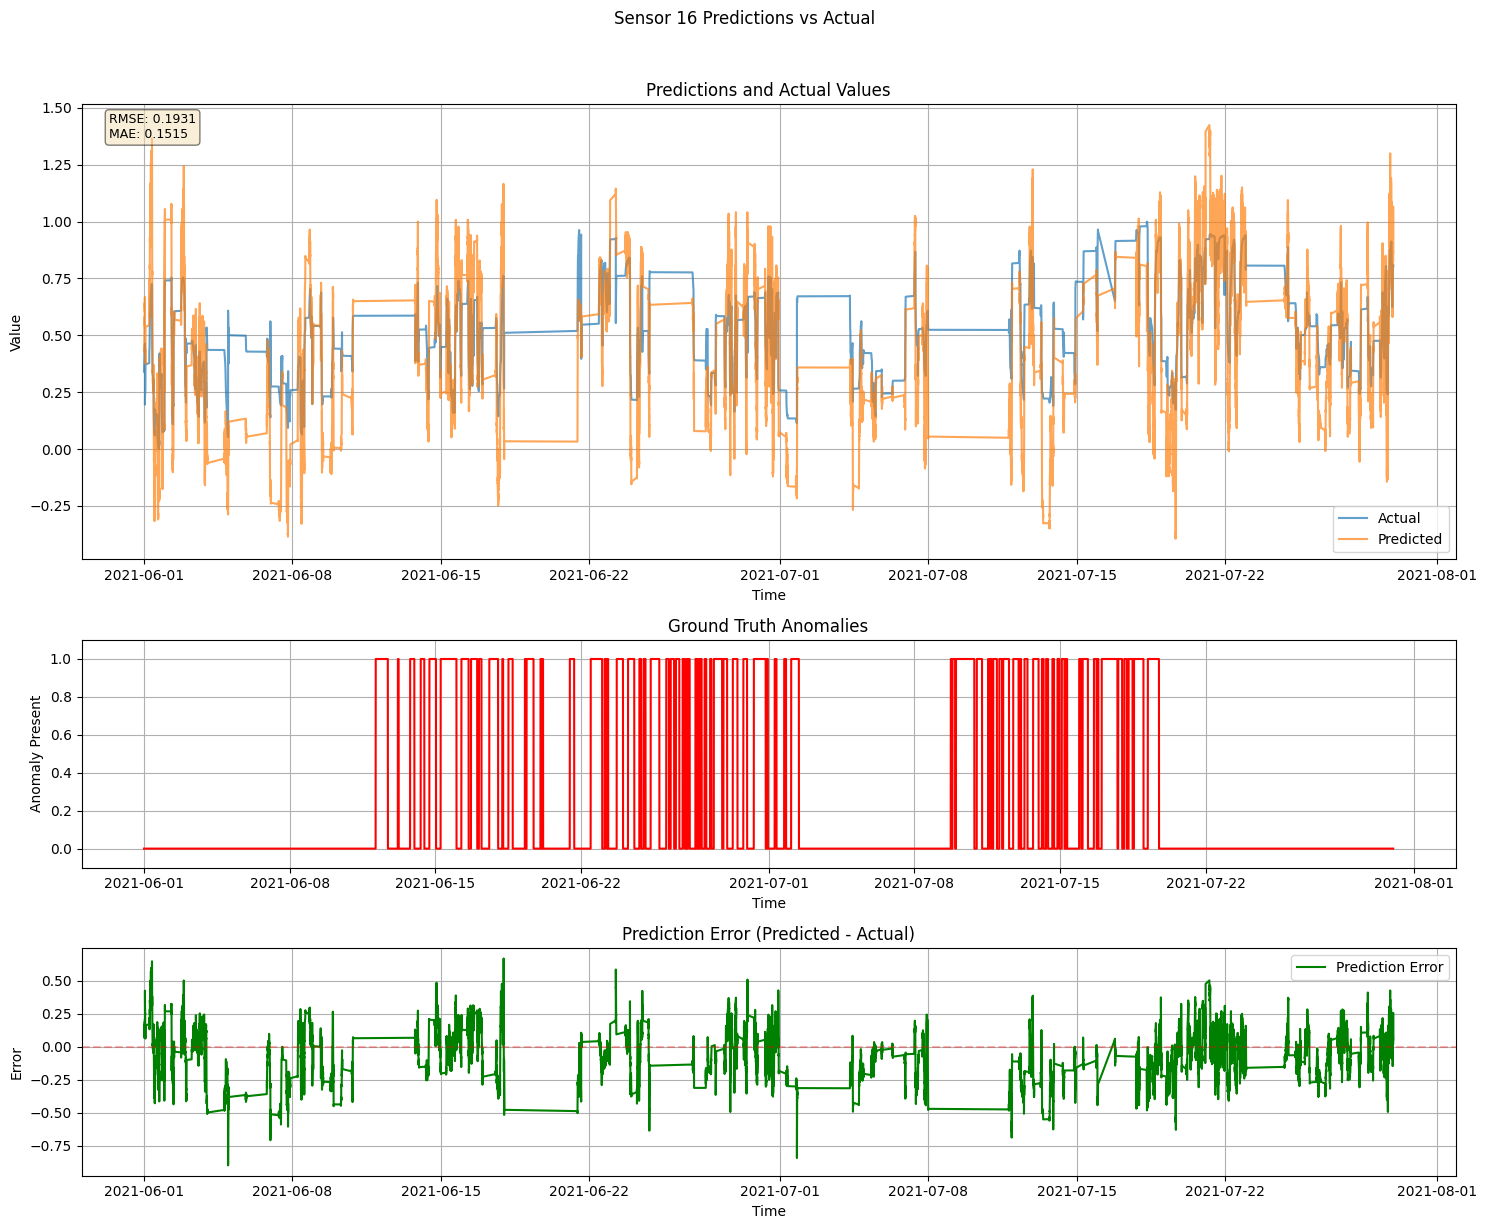

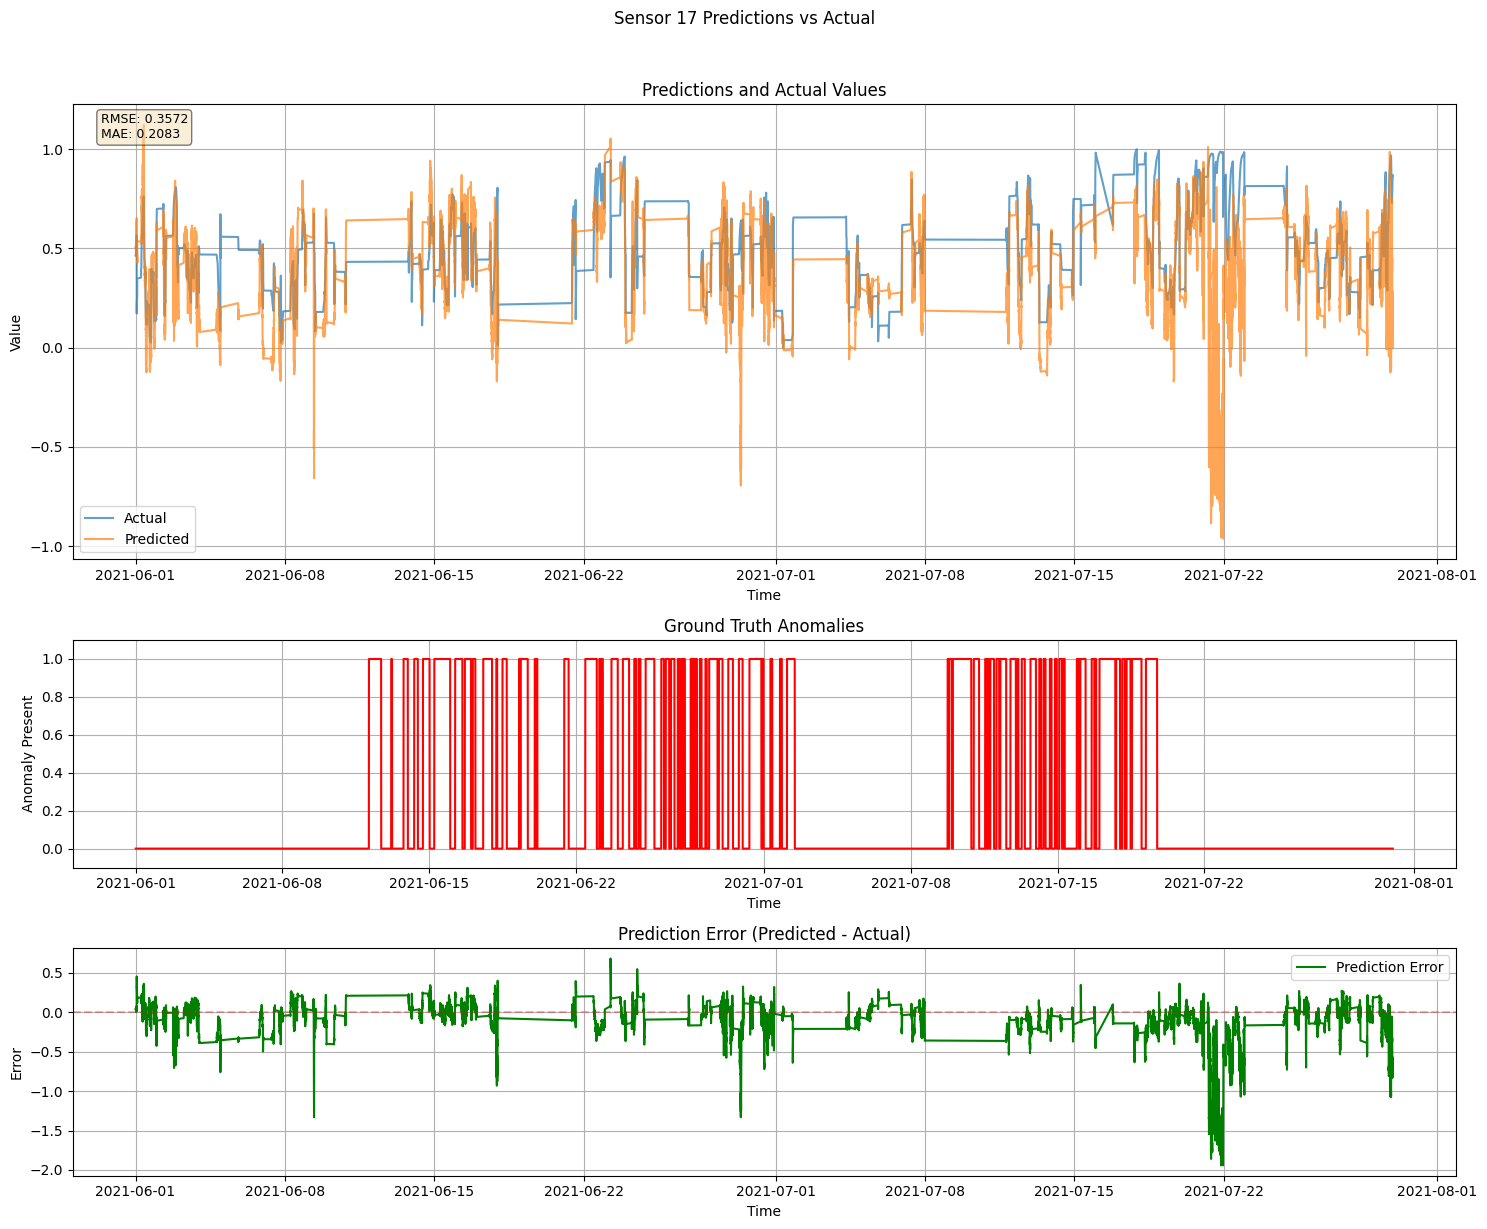

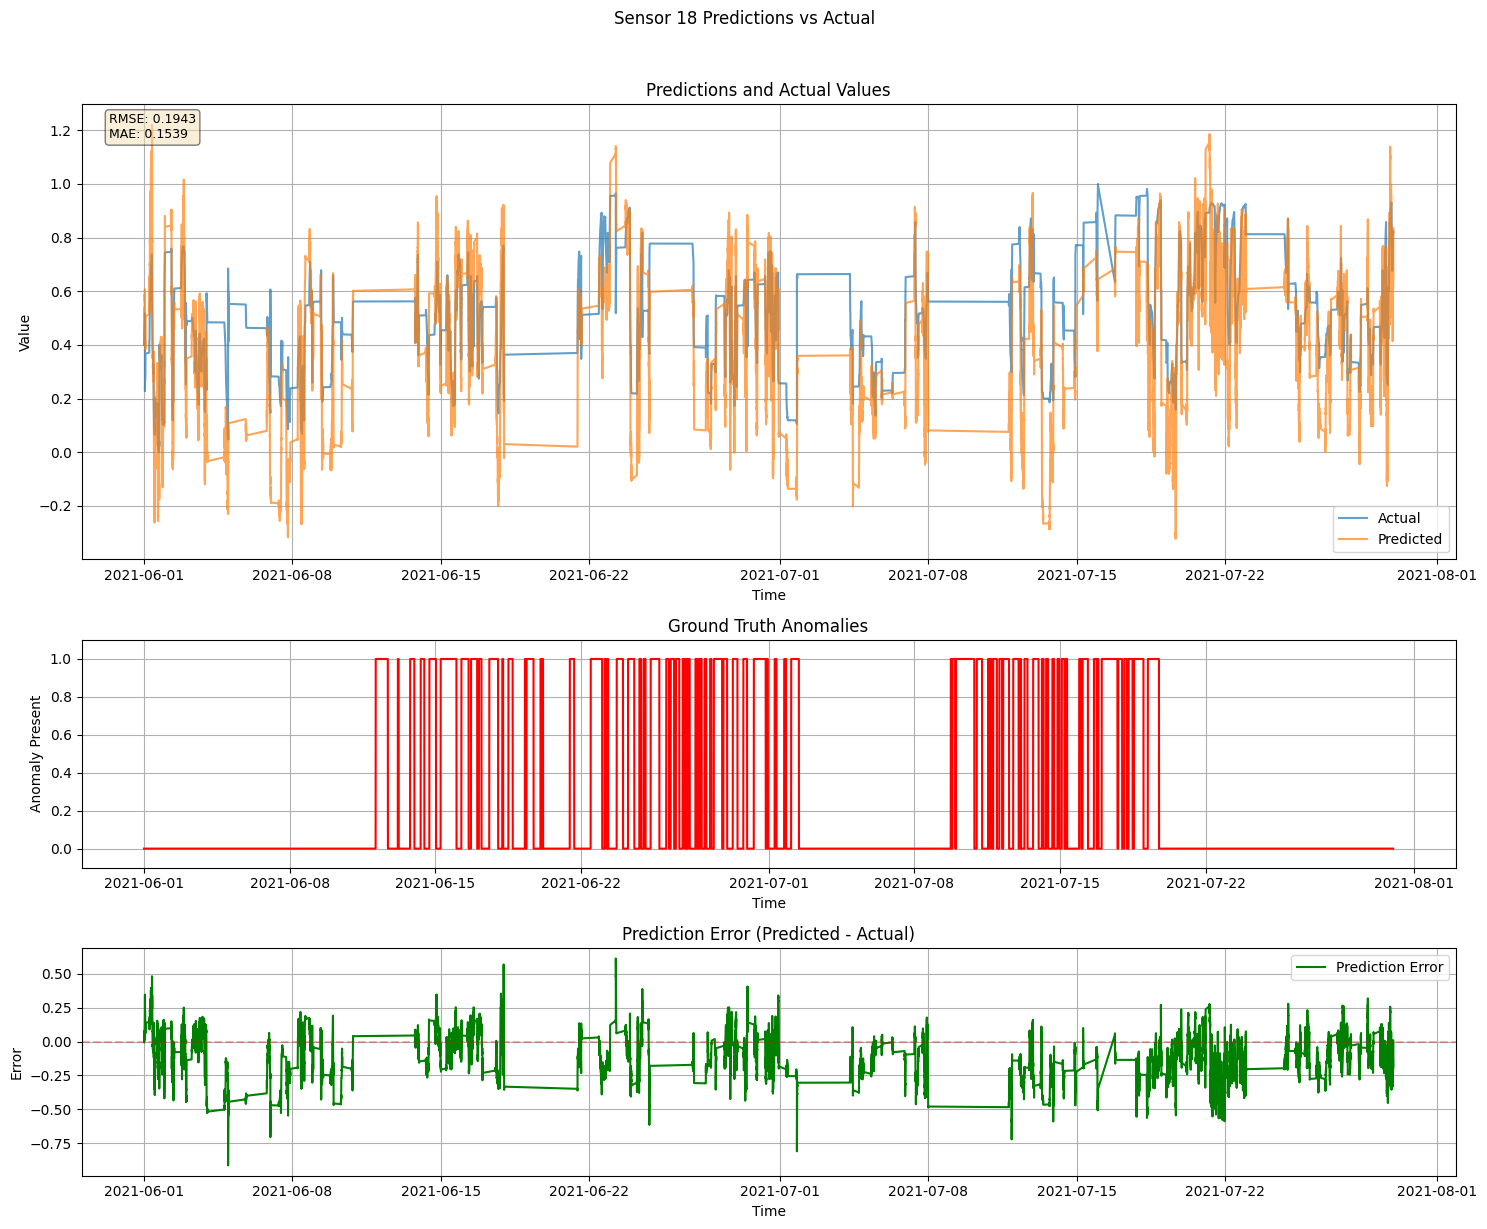

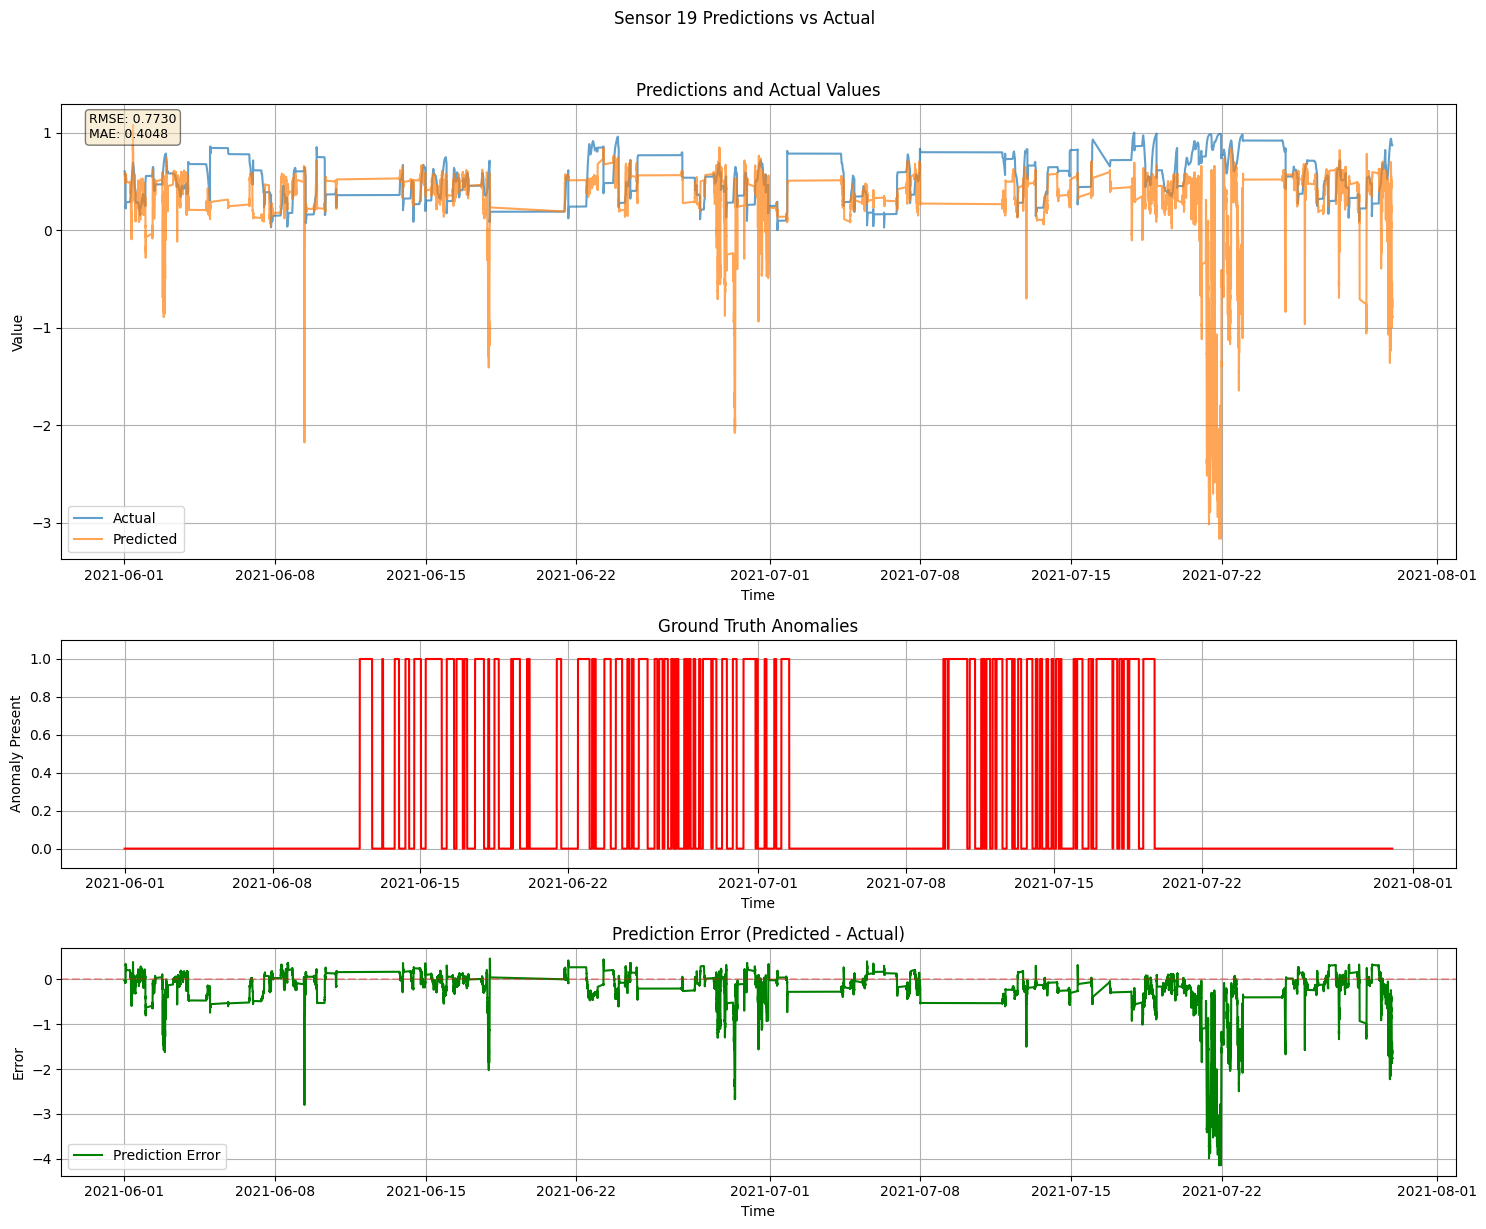

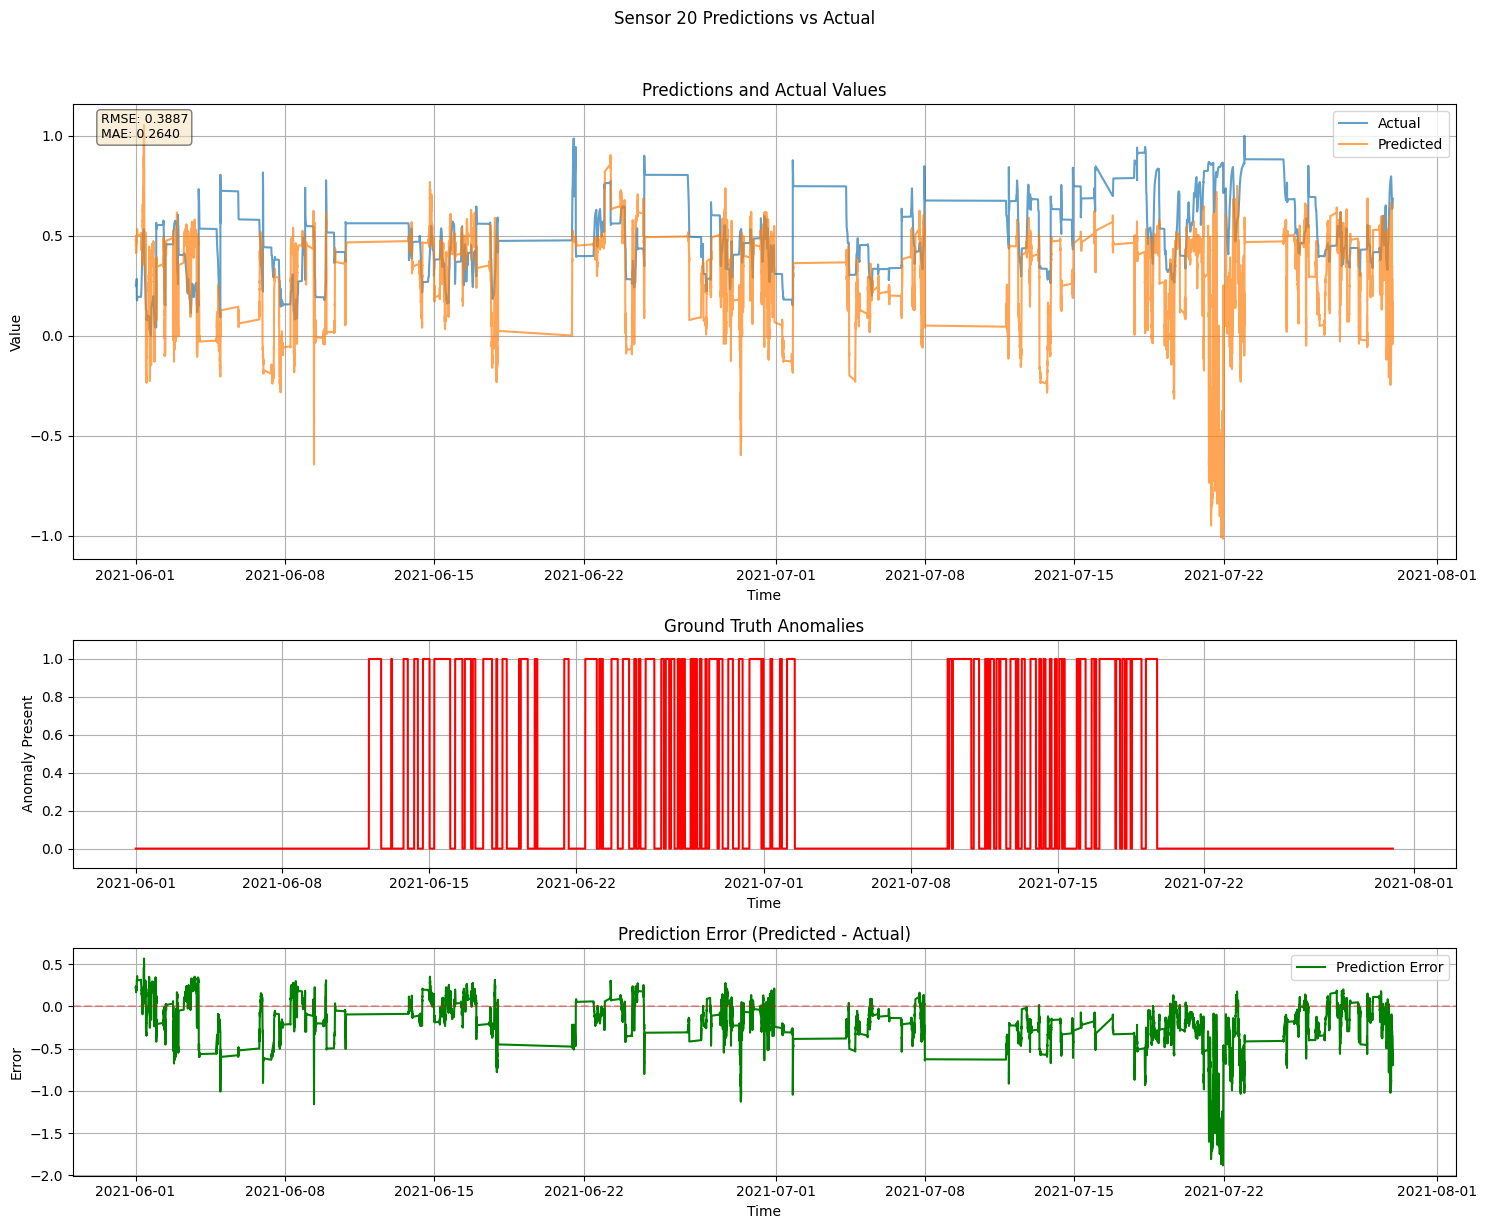

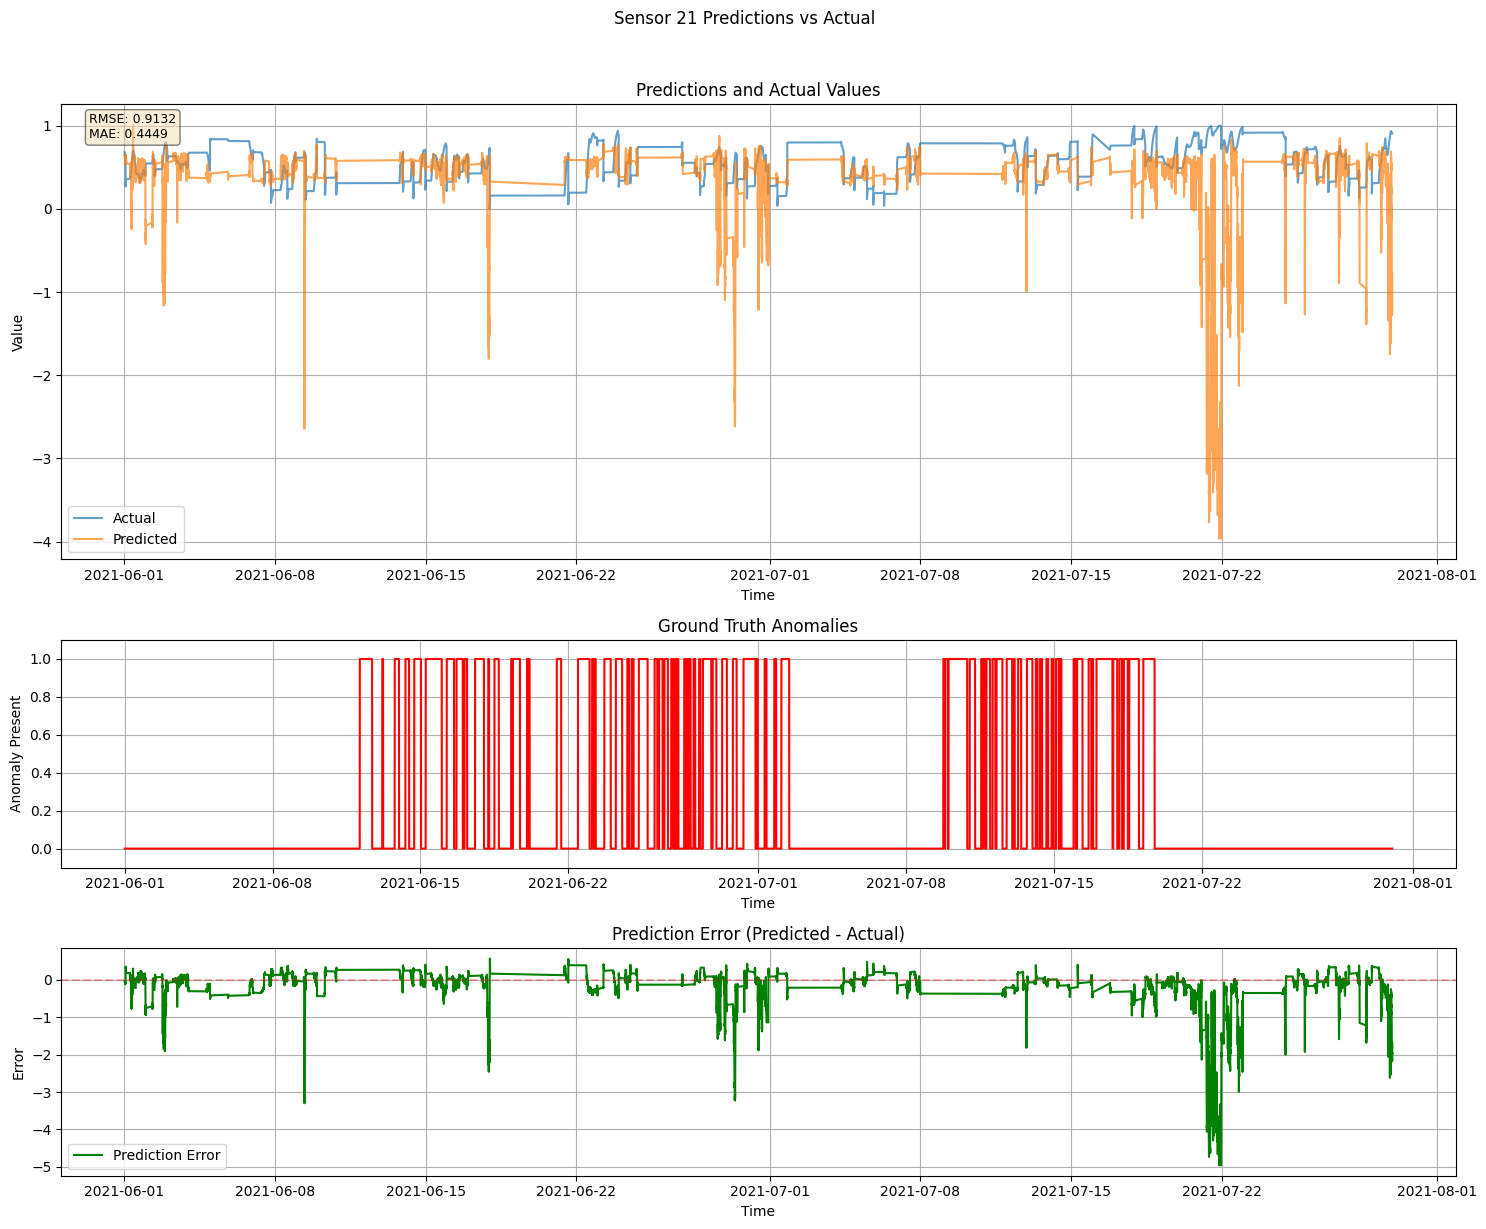

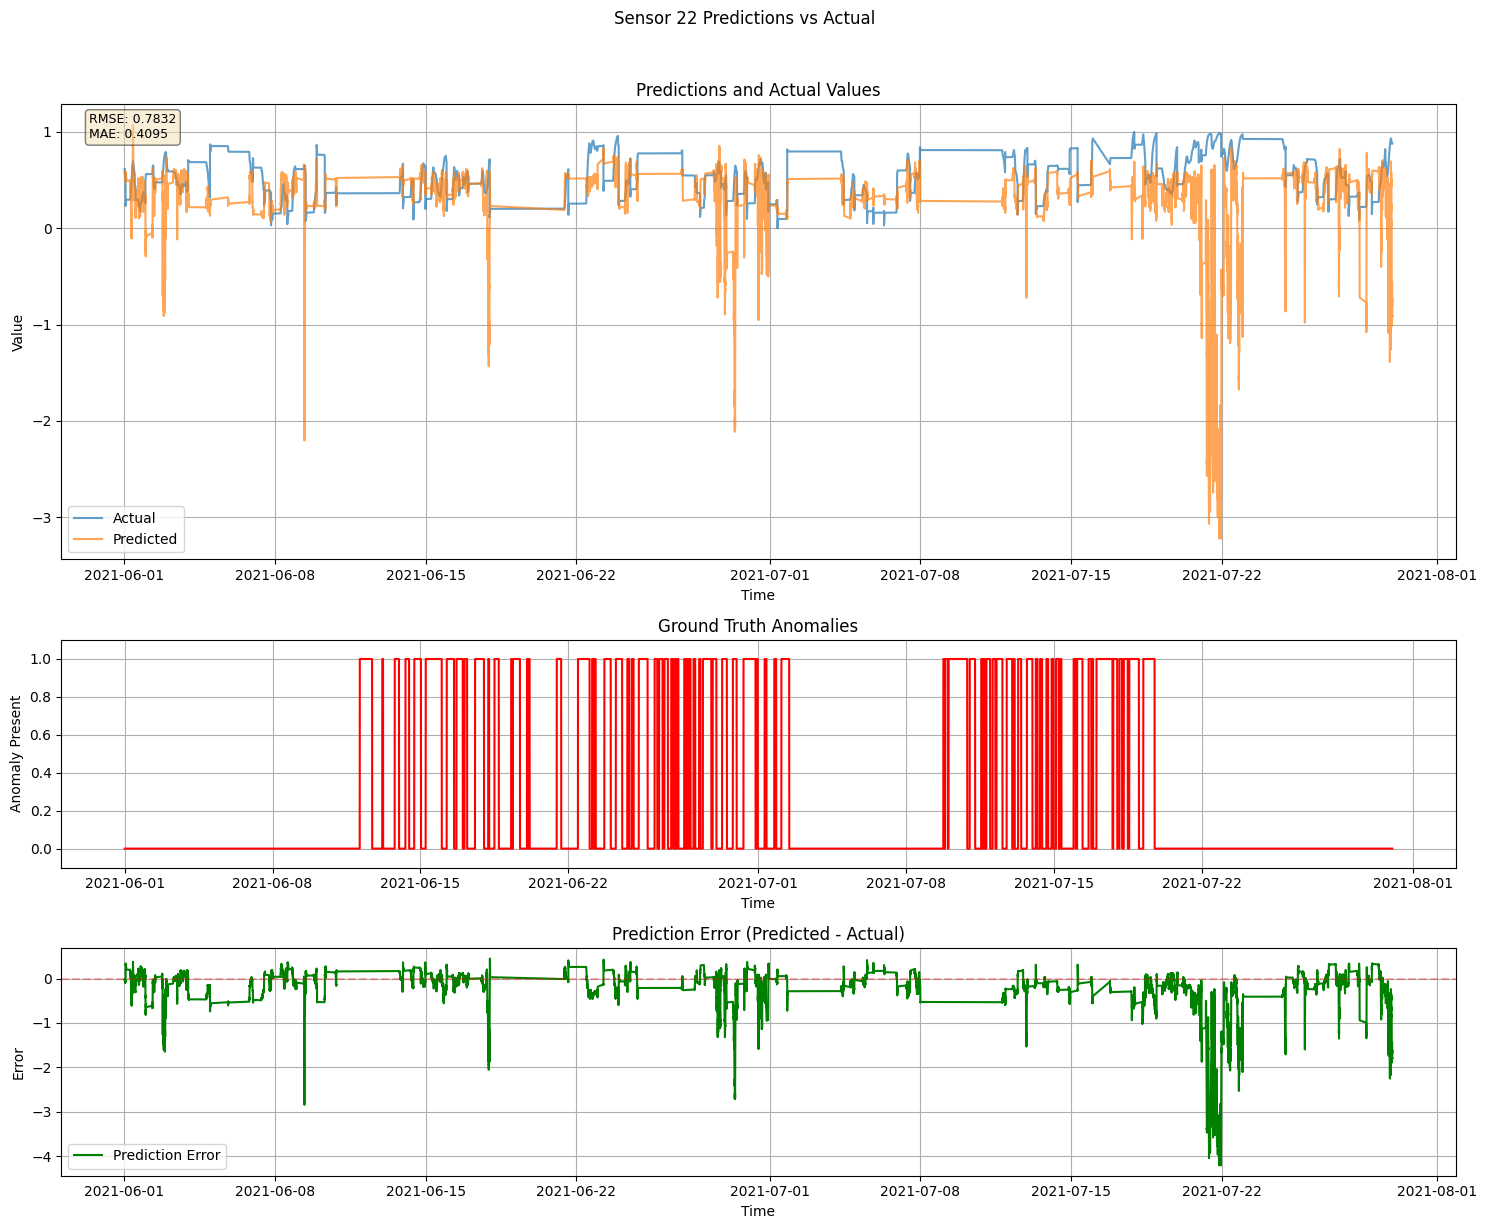

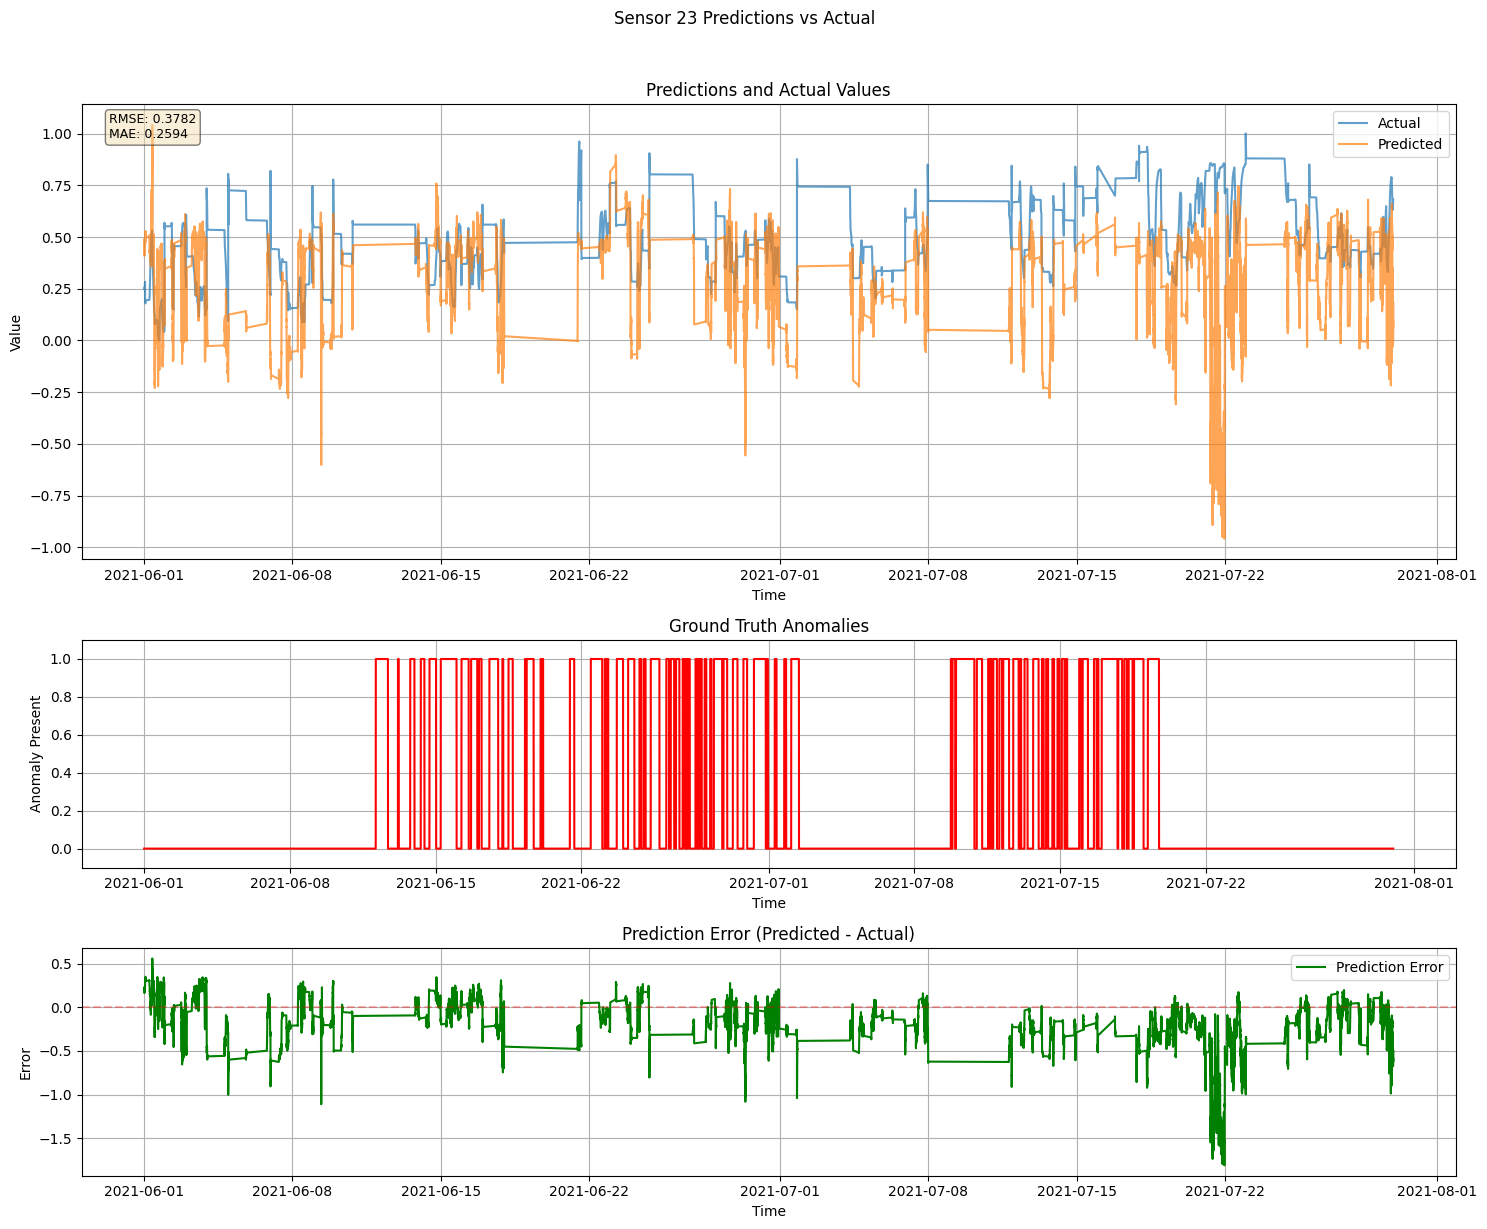

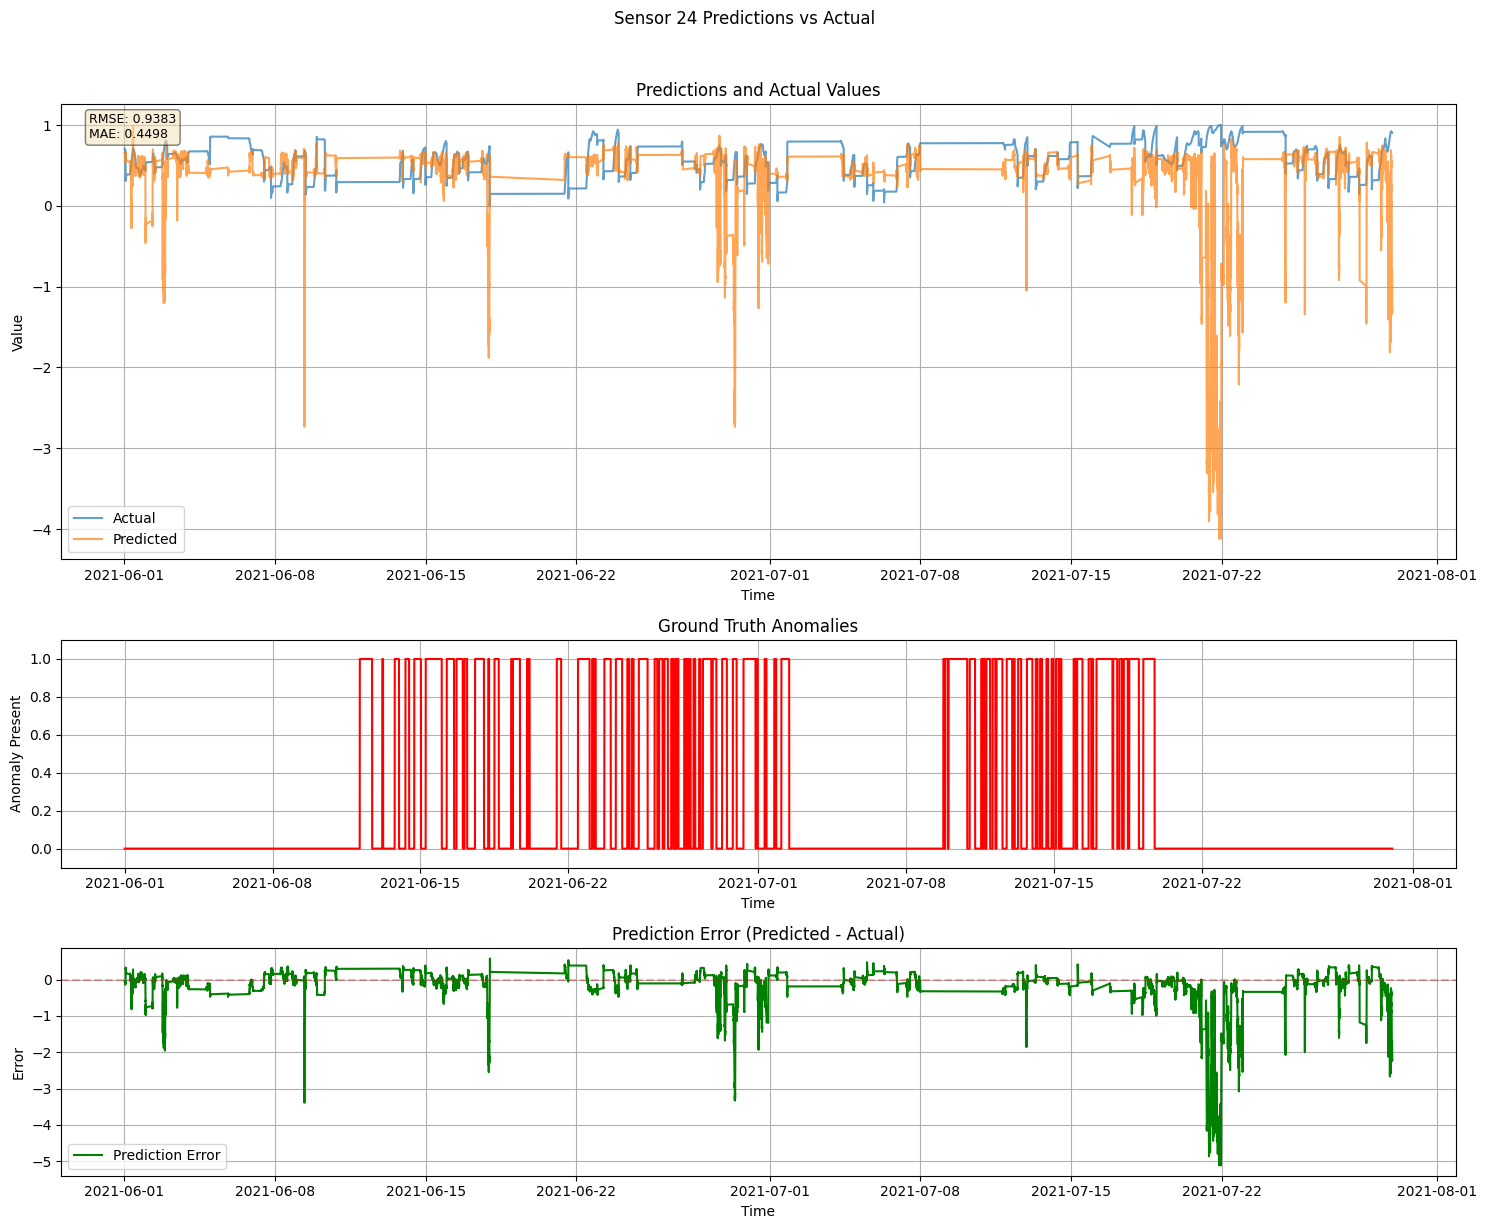

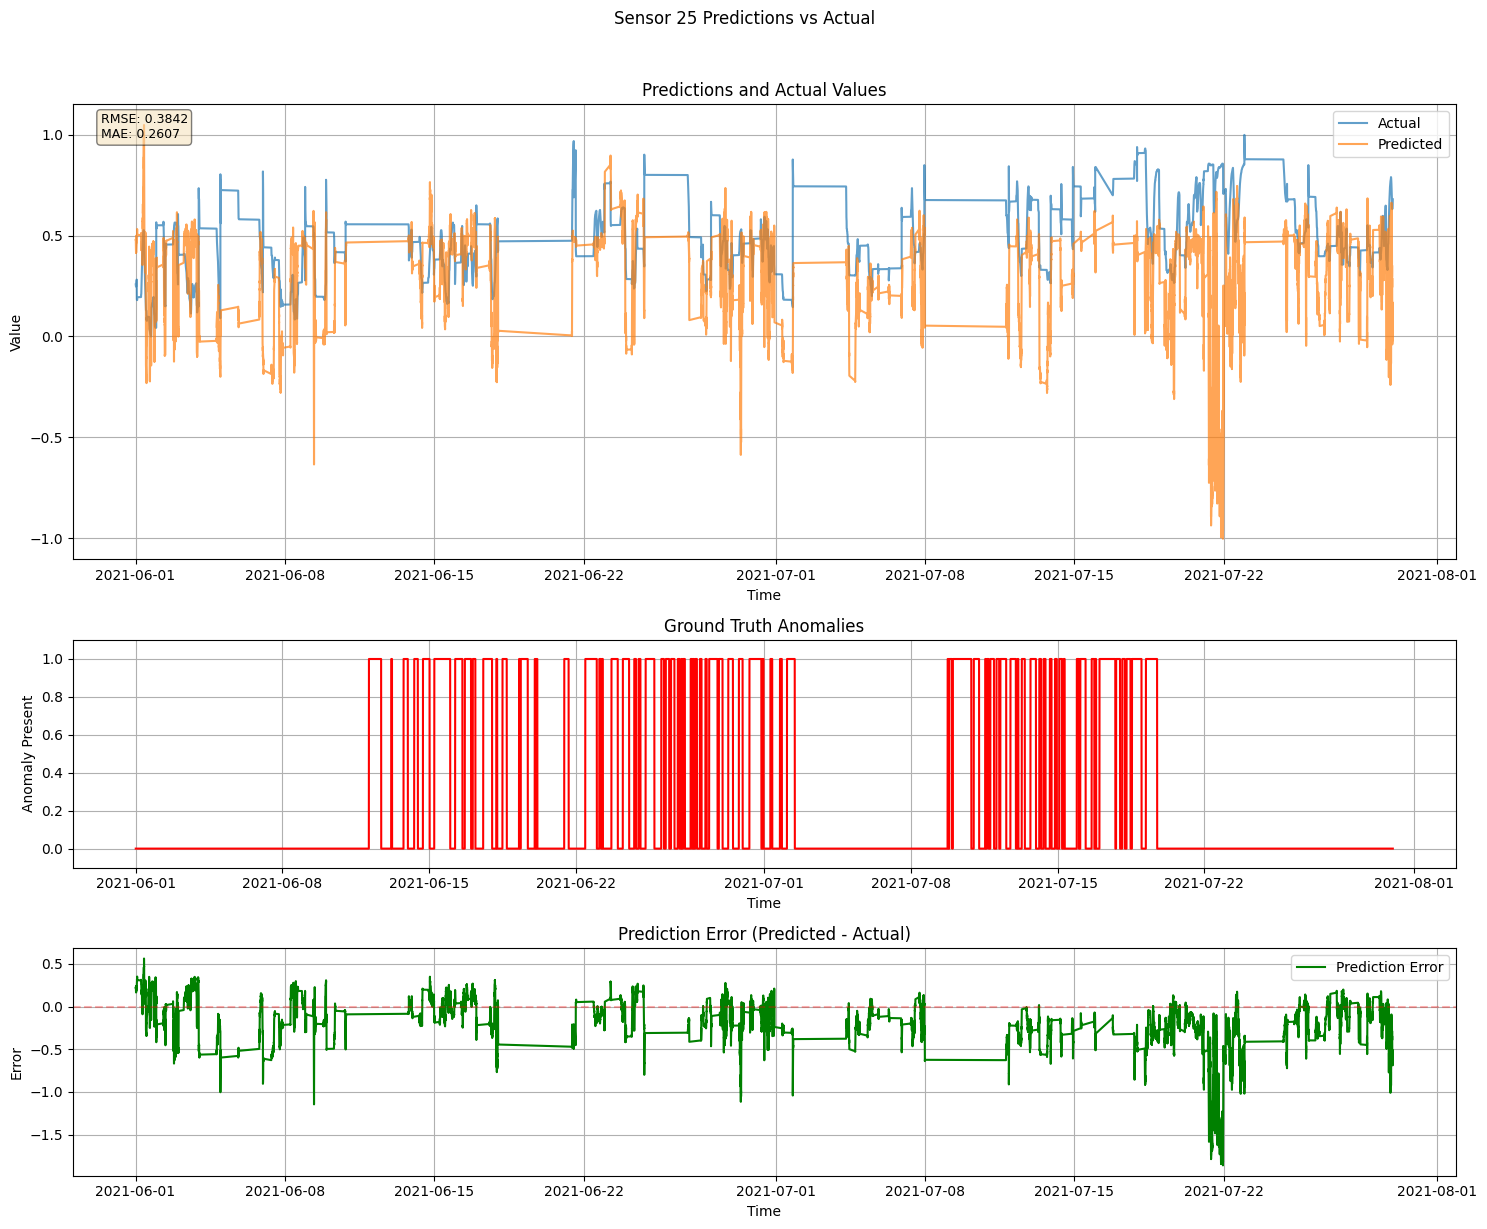

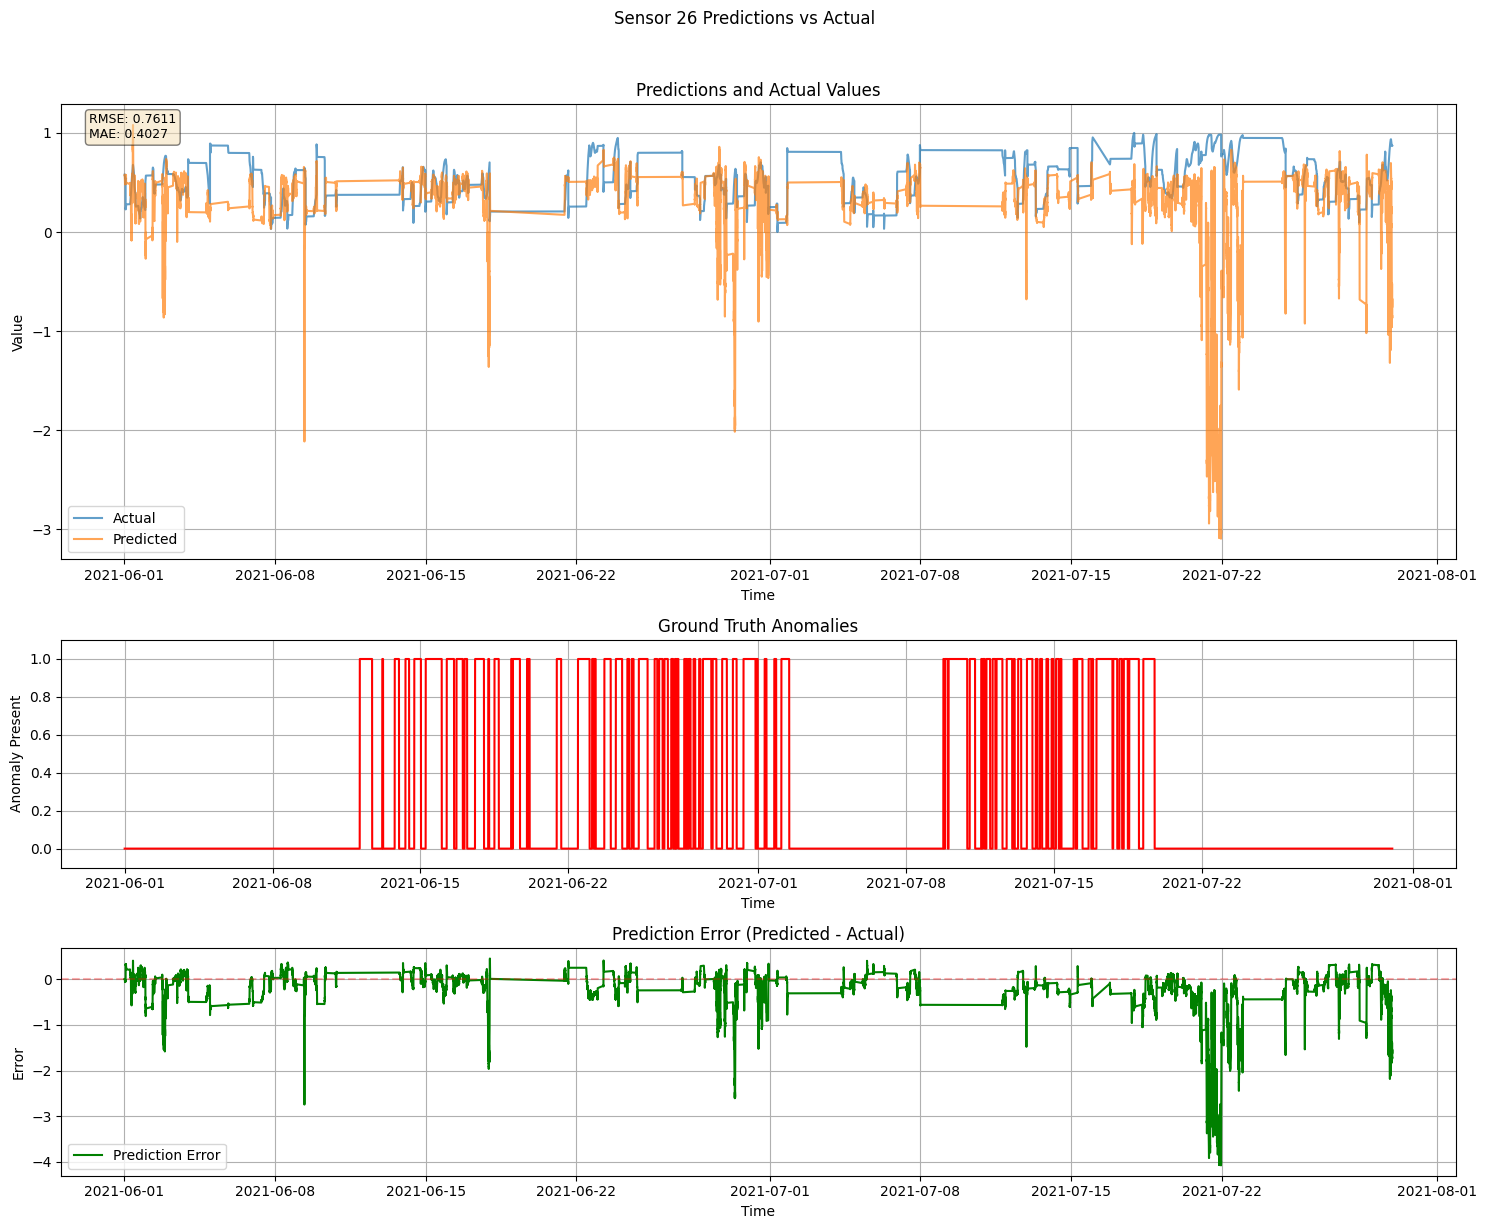

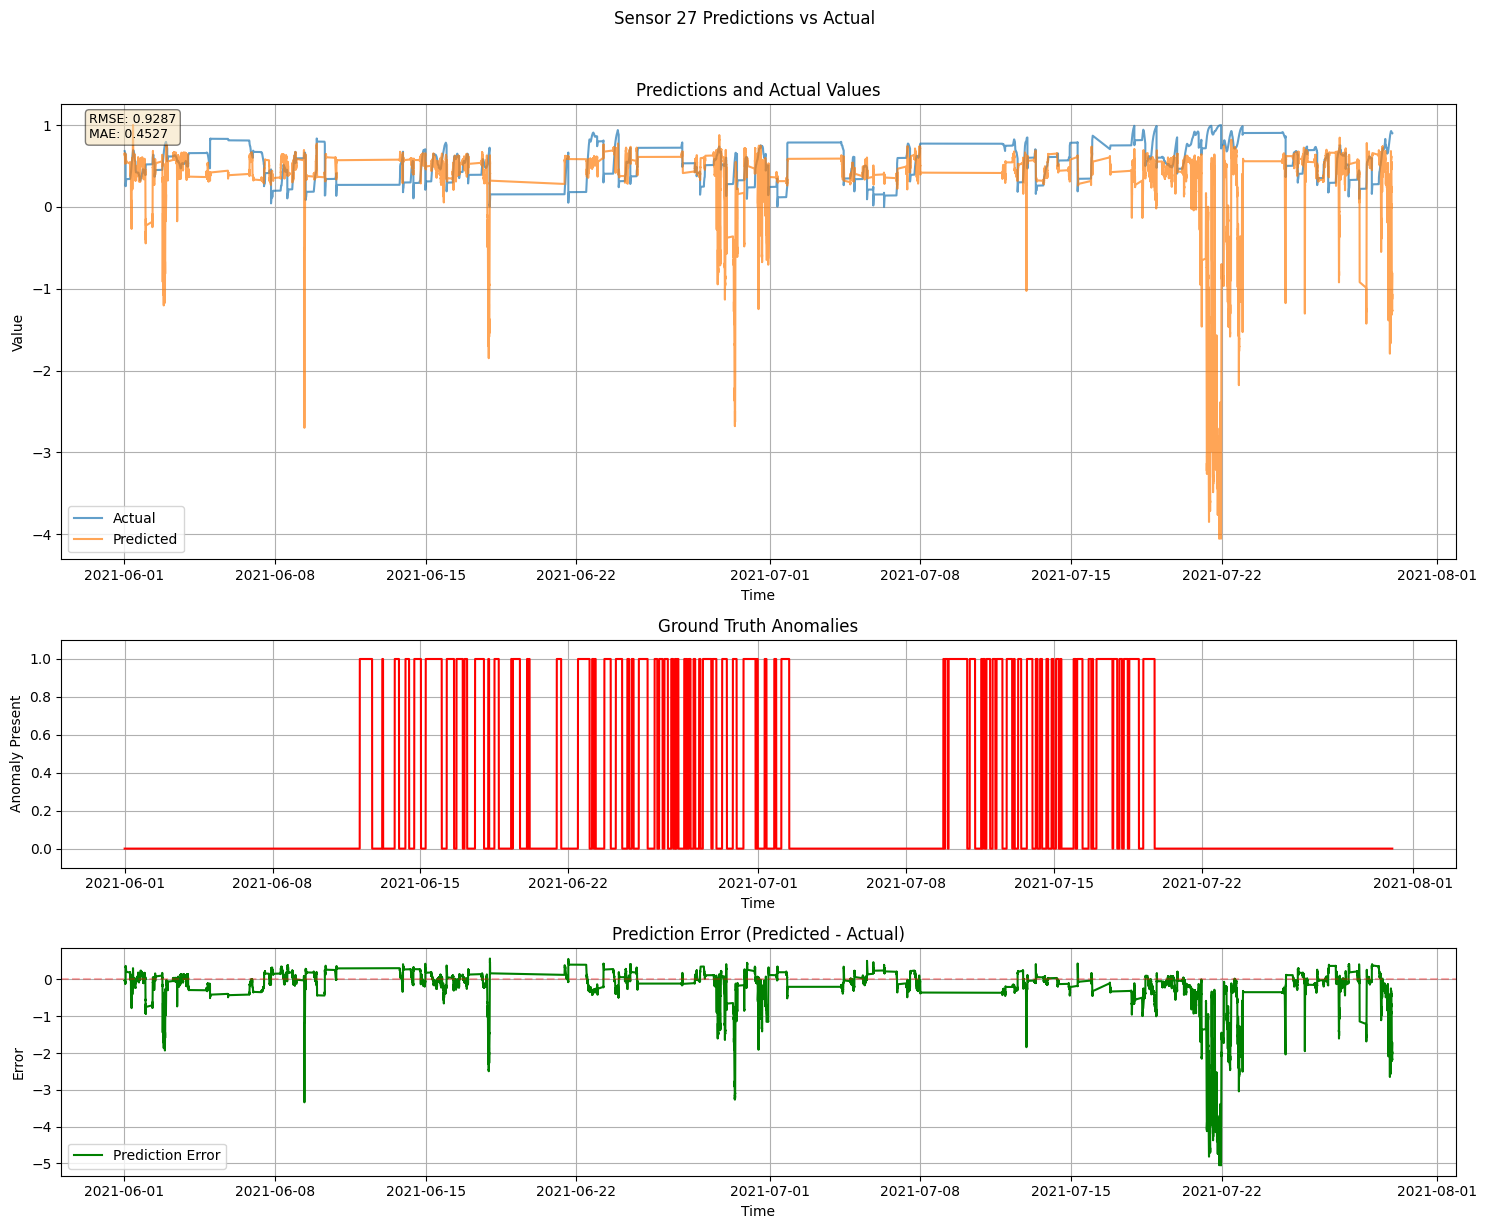

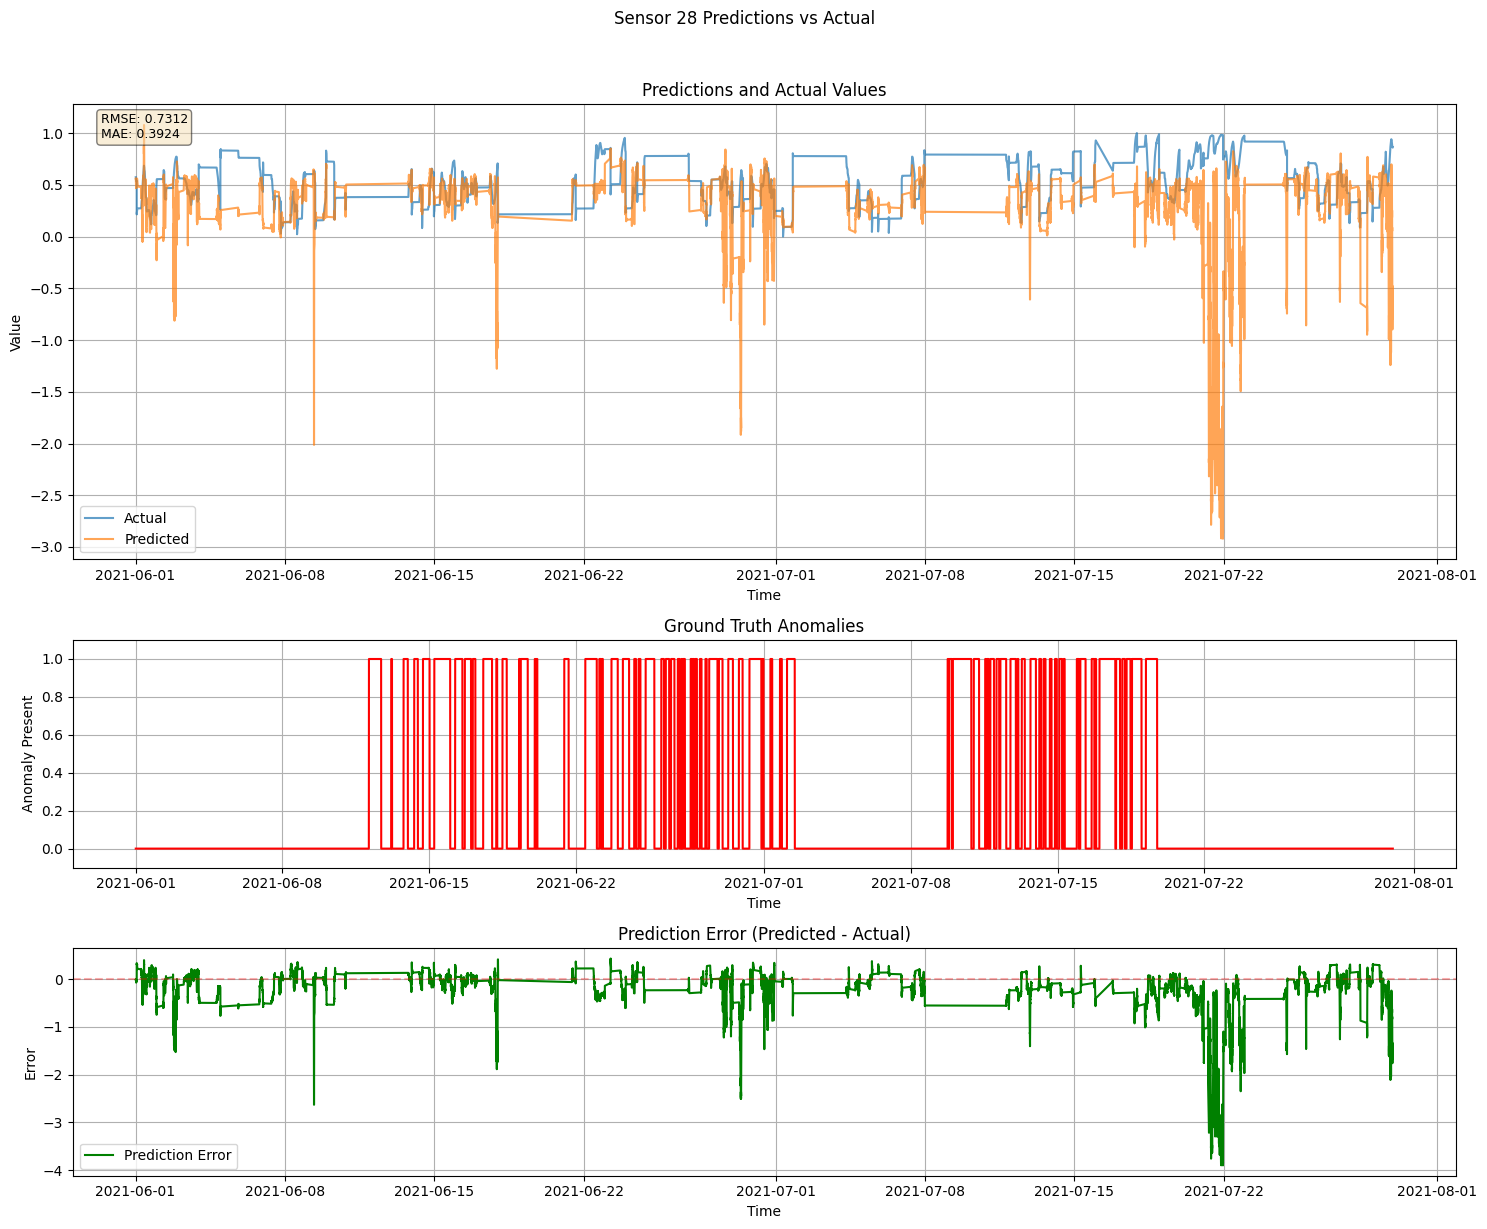

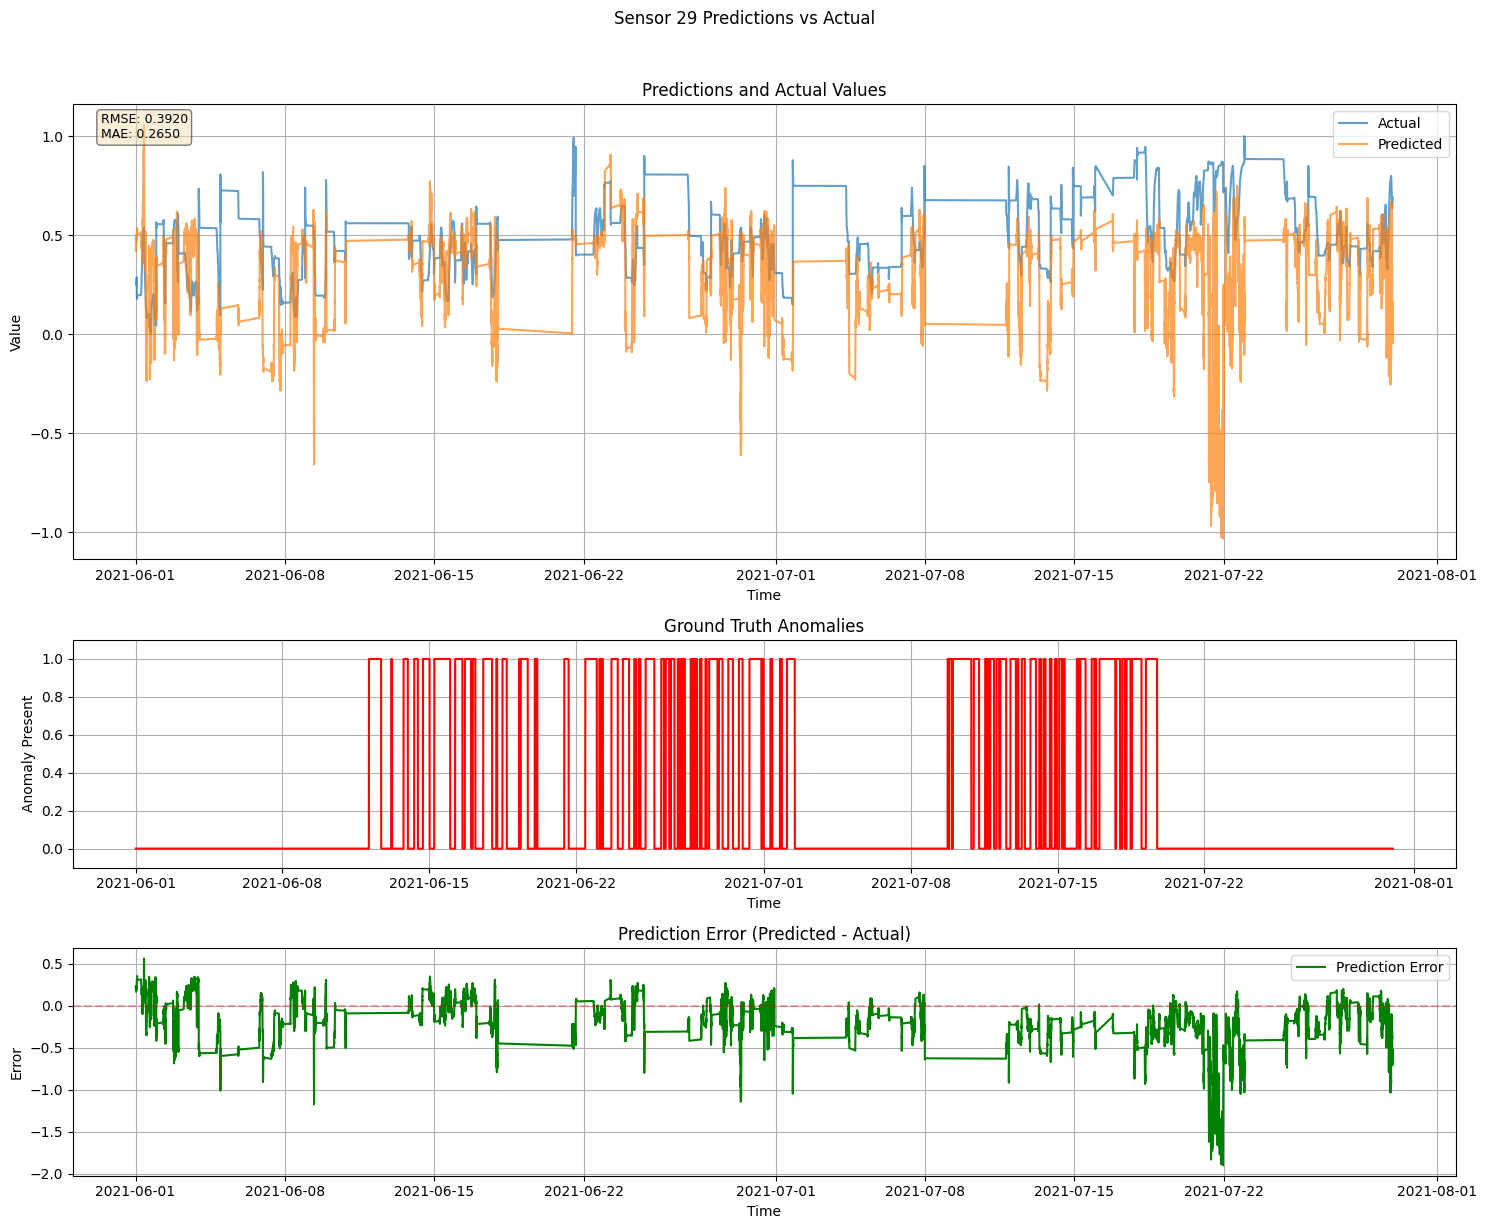

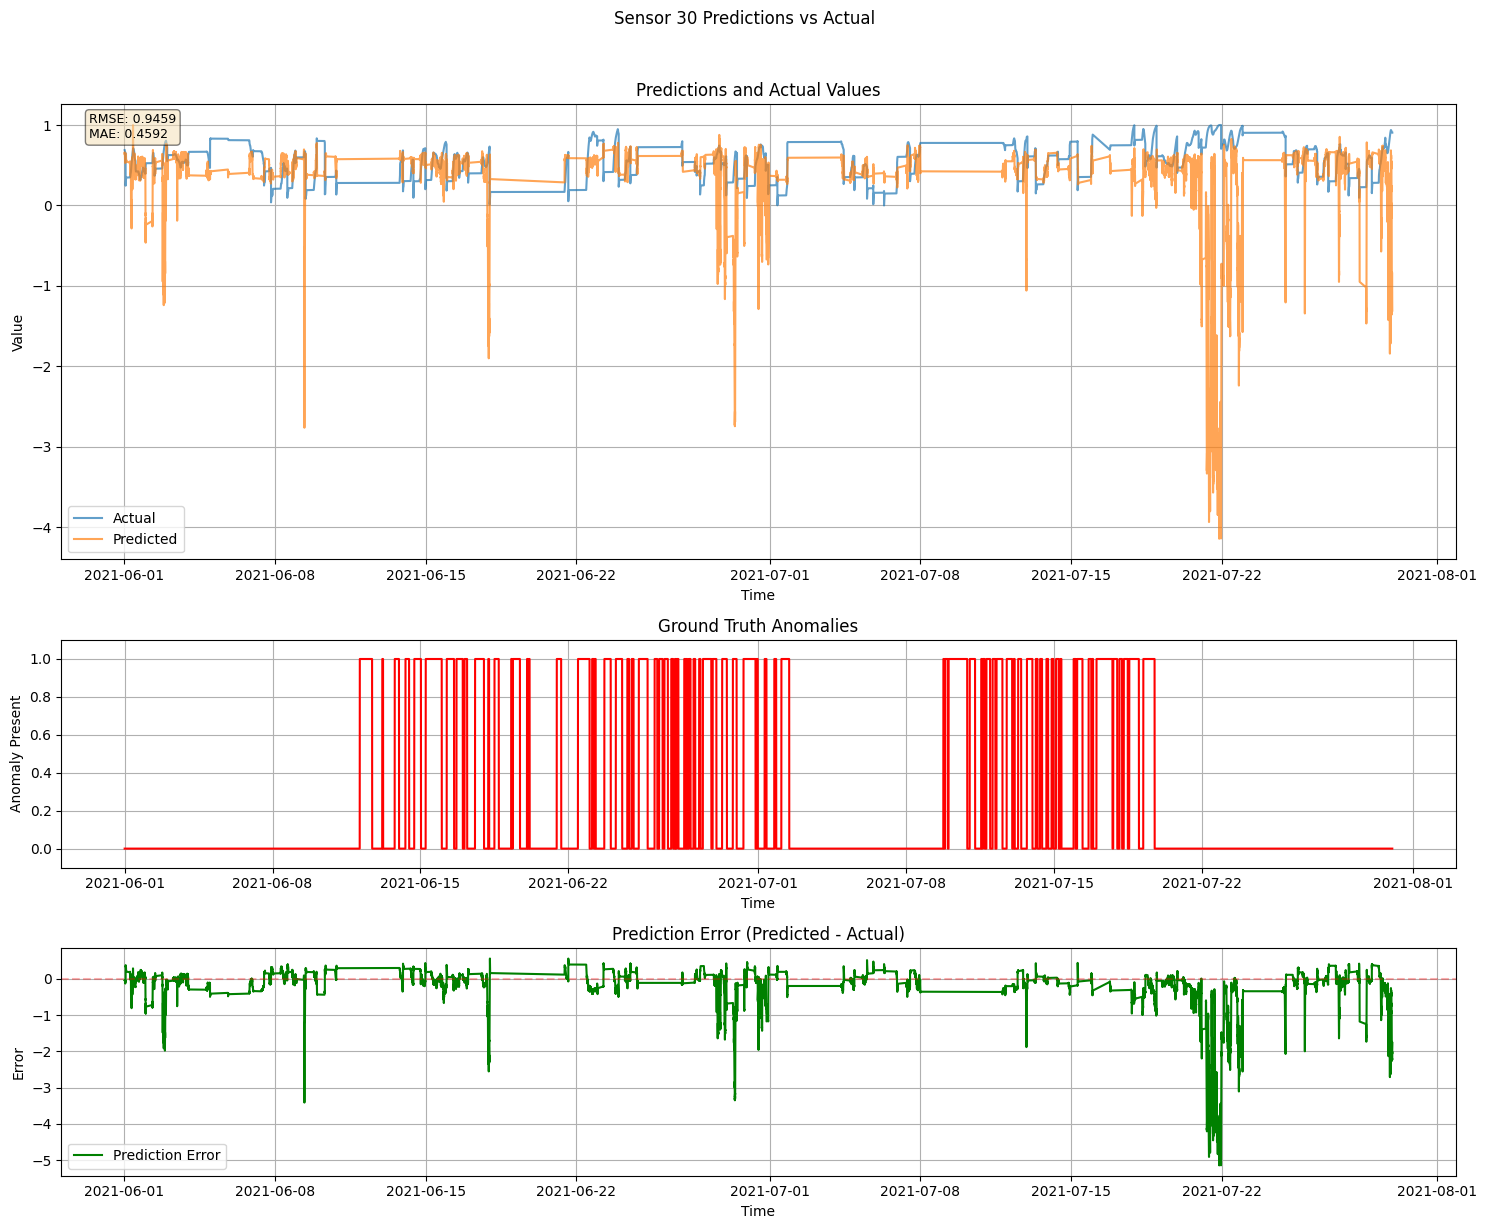


Overall Metrics:
Overall RMSE: 0.4953
Overall MAE: 0.2480


In [77]:
y_pred, y_test = evaluate_and_visualize(
    model,
    control_df_test,
    SELECTED_SENSOR_GROUP_TEST,
    ground_truth,
    ground_truth_index
)